In [ ]:
# ── Portable environment bootstrap · local ↔ Kaggle ──────────────────────────
# No-op on my machine (the notebook already runs from notebooks/, so ../data and
# ../reports resolve). On Kaggle it rebuilds that layout: it finds the cleaned
# dataset file whatever its name/compression (Kaggle may rename or extract it),
# detects the real format from the file's magic bytes, and materialises it at
# ../data/processed/df_clean.csv — so every relative path below keeps working.
import os, glob, gzip, zipfile, shutil
from pathlib import Path

if Path('/kaggle/input').exists():
    work   = Path('/kaggle/working')
    nb_dir = work / 'notebooks'
    nb_dir.mkdir(exist_ok=True)
    os.chdir(nb_dir)                                   # now '..' == /kaggle/working
    proc = work / 'data' / 'processed'
    proc.mkdir(parents=True, exist_ok=True)
    (work / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

    target = proc / 'df_clean.csv'
    if not target.exists():
        cands = [c for c in glob.glob('/kaggle/input/**/df_clean*', recursive=True)
                 if os.path.isfile(c)]
        if not cands:
            raise FileNotFoundError(
                "No df_clean.* file in the attached dataset — attach the Cyclistic dataset.")
        # prefer a real .csv, else the largest candidate
        csvs = [c for c in cands if c.lower().endswith('.csv')]
        src  = csvs[0] if csvs else max(cands, key=os.path.getsize)

        with open(src, 'rb') as f:
            magic = f.read(2)
        if magic == b'\x1f\x8b':                       # gzip
            with gzip.open(src, 'rb') as fi, open(target, 'wb') as fo:
                shutil.copyfileobj(fi, fo)
        elif magic == b'PK':                            # real zip archive
            with zipfile.ZipFile(src) as z:
                inner = [n for n in z.namelist() if n.lower().endswith('.csv')] or z.namelist()
                with z.open(inner[0]) as fi, open(target, 'wb') as fo:
                    shutil.copyfileobj(fi, fo)
        else:                                           # already plain-text CSV
            os.symlink(src, target)
        print(f"Kaggle detected — df_clean.csv ready (from {os.path.basename(src)})")
    else:
        print("Kaggle detected — df_clean.csv already present.")
else:
    print("Local environment — using the existing ../data and ../reports layout.")


# Table of Contents <a id='toc'></a>

- [Setup and Data Loading](#setup)
- [Feature Engineering](#features)
- [1. Overview: Usage Split by Day Type](#overview)
- [2. Temporal Patterns](#temporal)
  - [2.1 Intraday Usage Patterns (Hourly)](#hourly)
  - [2.2 Seasonal Patterns (Monthly)](#monthly)
- [3. POI Data Preparation](#poi_prep)
- [4. Linking Rides to POIs](#poi_link)
- [5. Balanced Sampling — Casual vs Member](#balancing)
- [6. Results: Usage Patterns by POI Category](#results)
  - [6.1 Ride Share by POI Category](#share)
  - [6.2 Trip Duration by POI Category](#duration)
  - [6.3 Hourly Usage by POI Category](#hourly_poi)
  - [6.4 Weekday vs Weekend by POI Category](#weekday_poi)
  - [6.5 Spatial View: Station POI Context Map](#spatial_poi)
- [7. Methodology and Limitations](#methodology)
- [8. Conclusions and Recommendations](#conclusions)
- [9. Saving Outputs](#saving)


---
# Setup and Data Loading <a id='setup'></a>
[↑ back to top](#toc)

**Input:** `df_clean.csv` — cleaned Divvy trip data (Jun 2025 – May 2026).

This notebook replaces the zoning-district spatial analysis with a **POI-based
analysis** that examines how casual and member riders behave differently around
five categories of Points of Interest: cycling infrastructure, schools & universities,
tourist attractions, business & office districts, and transport hubs.

Sections 1–2 carry over the feature engineering and temporal analysis from the
parent notebook to provide context.
Sections 3 onward contain the new POI pipeline.

**Additional libraries used in this notebook:**
| Library | Purpose |
|---------|---------|
| `contextily` | Basemap tiles for spatial maps |
| `geopandas` | Spatial data handling and projections |
| `scipy.spatial.cKDTree` | Fast nearest-neighbour lookup for station→POI assignment |
| `pyproj.Transformer` | CRS conversion (WGS84 → Web Mercator) |


In [1]:
import os
import time
import copy
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import geopandas as gpd
from shapely import wkt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator, FuncFormatter
from numba import jit, njit
from scipy.stats import chi2_contingency
from scipy.spatial import cKDTree
from pyproj import Transformer

try:
    import holidays as hol
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'holidays', '-q'])
    import holidays as hol

In [2]:
subfolder = '../data/processed'
filename  = 'df_clean.csv'
path      = os.path.join(subfolder, filename)

df_clean = pd.read_csv(path)

print(f"Rows    : {len(df_clean):,}")
print(f"Columns : {len(df_clean.columns)}")
print(f"Columns : {df_clean.columns.tolist()}")

Rows    : 5,614,731
Columns : 13
Columns : ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


---
# Feature Engineering <a id='features'></a>
[↑ back to top](#toc)

Before analysis, three derived features are added to the dataset:
1. **`trip_duration`** — ride length in minutes (capped to 1 min – 24 h to exclude outliers).
2. **`day_category`** — classifies each ride day as `weekday`, `weekend`, or `holiday` (using Illinois public holidays).
3. **`ride_date`** — date portion of `started_at` (used for normalization in time-series aggregations).

In [3]:
# converting in datetime ( if not already )
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['ended_at'] = pd.to_datetime(df_clean['ended_at'])
print(f'converting in datetime ( if not already ) started at:', df_clean['started_at'].dtype,f'ended at:',df_clean['ended_at'].dtype)

converting in datetime ( if not already ) started at: datetime64[ns] ended at: datetime64[ns]


In [4]:
# Backup before filtering outliers
df_original = df_clean.copy()

# Calculate duration in minutes
duration = ((df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds() / 60).round(2)

# Filter: keep trips between 1 minute and 24 hours (1 440 min)
df_clean = df_clean[(duration > 1) & (duration < 1440)].copy()
df_clean['trip_duration'] = ((df_clean['ended_at'] - df_clean['started_at'])
                              .dt.total_seconds() / 60).round(2)

print(f"From {len(df_original):,} to {len(df_clean):,} rows "
      f"({(1 - len(df_clean)/len(df_original))*100:.2f}% removed as duration outliers)")
print(f"trip_duration — min: {df_clean['trip_duration'].min():.1f} min  "
      f"max: {df_clean['trip_duration'].max():.1f} min  "
      f"median: {df_clean['trip_duration'].median():.1f} min")

From 5,614,731 to 5,462,857 rows (2.70% removed as duration outliers)
trip_duration — min: 1.0 min  max: 1440.0 min  median: 9.7 min


### Day category: weekday / weekend / holiday

Illinois public holidays are identified using the `holidays` library.  
A vectorized approach assigns each trip a day type without iterating row by row.

[↑ back to top](#toc)

In [5]:
start_date = pd.to_datetime(df_clean['started_at']).min().normalize().date()
end_date   = pd.to_datetime(df_clean['started_at']).max().normalize().date()

us_holidays  = hol.US(state='IL', years=[start_date.year, end_date.year])
holiday_set  = {h for h in us_holidays if start_date <= h <= end_date}
holiday_dates = pd.to_datetime(sorted(holiday_set))

print(f"Date range       : {start_date} → {end_date}")
print(f"Illinois holidays in range : {len(holiday_set)}")

Date range       : 2025-03-31 → 2026-03-31
Illinois holidays in range : 13


In [6]:
# =====================================================
# STEP 1: CREATE DAY CATEGORY COLUMN (VECTORIZED)
# =====================================================
print(" ")
print('STEP 1: CREATE DAY CATEGORY COLUMN (VECTORIZED)...')
print(" ")
# Ensure started_at is datetime (already done, but safe check)
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])

# Extract date only (without time) for holiday matching
df_clean['date_only'] = df_clean['started_at'].dt.date  

# Flag holidays using Chicago 2025-2026 holiday list (13 dates)
df_clean['is_holiday'] = df_clean['date_only'].isin(holiday_set)

# Categorize days using nested np.where (vectorized, fast on 5M rows):
# 1. If holiday → 'holiday' 
# 2. Else if weekday (Mon-Fri, weekday 0-4) → 'weekday' 
# 3. Else (Sat-Sun) → 'weekend'
df_clean['day_category'] = np.where(
    df_clean['is_holiday'], 'holiday', 
    np.where(df_clean['started_at'].dt.weekday < 5, 'weekday', 'weekend')
)
print('Total ride distribution:')
print(df_clean['day_category'].value_counts())
# =====================================================
# STEP 2: CREATE 4 SEGMENTED DATAFRAMES
# 2 groups x 2 customer types = 4 total DataFrames
# =====================================================


 
STEP 1: CREATE DAY CATEGORY COLUMN (VECTORIZED)...
 


Total ride distribution:
day_category
weekday    3768927
weekend    1541113
holiday     152817
Name: count, dtype: int64


The three categories split the dataset into distinct behavioural contexts:  
- **Weekday** — likely dominated by commuters (members).  
- **Weekend + Holiday** — likely dominated by leisure rides (casuals).  
The pie chart in Section 1 will test this hypothesis at a high level.

[↑ back to top](#toc)

---
# 1. Overview: Member vs Casual Usage Split <a id='overview'></a>
[↑ back to top](#toc)

**Macro view:** what fraction of rides does each user type take on weekdays vs. weekends/holidays?  
A clear asymmetry here would be the first signal that the two groups have different use cases —  
which we will then confirm and detail in the temporal and spatial analyses below.

In [7]:
import matplotlib.pyplot as plt

# =====================================================
# STEP 0: CREATE A DATE COLUMN
# =====================================================
import time
t0 = time.time()

df_clean = df_clean.copy()

# ✅ OPT: specify format to avoid auto-inference (much faster on large datasets)
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'], format='mixed')
df_clean['ended_at']   = pd.to_datetime(df_clean['ended_at'],   format='mixed')
df_clean = df_clean.drop(columns=['date_only'], errors='ignore')
df_clean['ride_date']  = df_clean['started_at'].dt.normalize()

# ✅ OPT: single mapped column instead of repeated boolean filters
df_clean['day_cat_simple'] = df_clean['day_category'].map(
    lambda x: 'weekday' if x == 'weekday' else 'weekend'
)

print("=" * 55)
print("STEP 0 ✅ Date columns converted & 'ride_date' created")
print(f"  → Total rows  : {len(df_clean):,}")
print(f"  → Date range  : {df_clean['ride_date'].min().date()} → {df_clean['ride_date'].max().date()}")
print(f"  → Unique days : {df_clean['ride_date'].nunique()}")
print(f"  ⏱ Step 0: {time.time()-t0:.3f}s"); t0 = time.time()

# =====================================================
# STEP 1: SEGMENT COUNTS (no copies, just filters for display)
# =====================================================

# ✅ OPT: use value_counts instead of creating 4 dataframes
segment_counts = df_clean.groupby(['day_cat_simple', 'member_casual']).size()

print("\n" + "=" * 55)
print("STEP 1 ✅ Dataset split into 4 segments (no copies)")
print(f"  → Weekday  | Member : {segment_counts.get(('weekday','member'), 0):>8,} rides")
print(f"  → Weekday  | Casual : {segment_counts.get(('weekday','casual'), 0):>8,} rides")
print(f"  → Weekend  | Member : {segment_counts.get(('weekend','member'), 0):>8,} rides")
print(f"  → Weekend  | Casual : {segment_counts.get(('weekend','casual'), 0):>8,} rides")
print(f"  → Total   (check)  : {segment_counts.sum():>8,} rides")
print(f"  ⏱ Step 1: {time.time()-t0:.3f}s"); t0 = time.time()

# =====================================================
# STEP 2 + 3: SINGLE GROUPED CALCULATION (replaces function + 4 calls)
# =====================================================

# ✅ OPT: ONE groupby replaces 4 filtered copies + 4 function calls
stats = (
    df_clean
    .groupby(['day_cat_simple', 'member_casual'])
    .agg(
        total_minutes=('trip_duration', 'sum'),
        total_days=('ride_date',        'nunique')
    )
)
stats['avg_min_per_day'] = stats['total_minutes'] / stats['total_days']

# Extract values (same variable names as before for compatibility)
weekday_member_tot_min      = stats.loc[('weekday','member'), 'total_minutes']
weekday_member_days         = stats.loc[('weekday','member'), 'total_days']
weekday_member_avg_min_day  = stats.loc[('weekday','member'), 'avg_min_per_day']

weekday_casual_tot_min      = stats.loc[('weekday','casual'), 'total_minutes']
weekday_casual_days         = stats.loc[('weekday','casual'), 'total_days']
weekday_casual_avg_min_day  = stats.loc[('weekday','casual'), 'avg_min_per_day']

weekend_member_tot_min      = stats.loc[('weekend','member'), 'total_minutes']
weekend_member_days         = stats.loc[('weekend','member'), 'total_days']
weekend_member_avg_min_day  = stats.loc[('weekend','member'), 'avg_min_per_day']

weekend_casual_tot_min      = stats.loc[('weekend','casual'), 'total_minutes']
weekend_casual_days         = stats.loc[('weekend','casual'), 'total_days']
weekend_casual_avg_min_day  = stats.loc[('weekend','casual'), 'avg_min_per_day']

print("\n" + "=" * 55)
print("STEP 2+3 ✅ Single groupby replaces function + 4 calls")
print(f"  {'Segment':<22} {'Tot. min':>10} {'Days':>6} {'Avg min/day':>12}")
print(f"  {'-'*52}")
print(f"  {'Weekday  | Member':<22} {weekday_member_tot_min:>10,.0f} {weekday_member_days:>6} {weekday_member_avg_min_day:>12,.1f}")
print(f"  {'Weekday  | Casual':<22} {weekday_casual_tot_min:>10,.0f} {weekday_casual_days:>6} {weekday_casual_avg_min_day:>12,.1f}")
print(f"  {'Weekend  | Member':<22} {weekend_member_tot_min:>10,.0f} {weekend_member_days:>6} {weekend_member_avg_min_day:>12,.1f}")
print(f"  {'Weekend  | Casual':<22} {weekend_casual_tot_min:>10,.0f} {weekend_casual_days:>6} {weekend_casual_avg_min_day:>12,.1f}")
print(f"  ⏱ Step 2+3: {time.time()-t0:.3f}s"); t0 = time.time()

# =====================================================
# STEP 4: PIE CHART PERCENTAGES
# =====================================================
member_total_avg = weekday_member_avg_min_day + weekend_member_avg_min_day
casual_total_avg = weekday_casual_avg_min_day + weekend_casual_avg_min_day

member_weekday_pct = (weekday_member_avg_min_day / member_total_avg) * 100 if member_total_avg > 0 else 0
member_weekend_pct = 100 - member_weekday_pct

casual_weekday_pct = (weekday_casual_avg_min_day / casual_total_avg) * 100 if casual_total_avg > 0 else 0
casual_weekend_pct = 100 - casual_weekday_pct

print("\n" + "=" * 55)
print("STEP 4 ✅ Pie chart percentages computed")
print(f"  → MEMBER  — Weekday: {member_weekday_pct:.1f}%  |  Weekend: {member_weekend_pct:.1f}%")
print(f"  → CASUAL  — Weekday: {casual_weekday_pct:.1f}%  |  Weekend: {casual_weekend_pct:.1f}%")
print(f"  ⏱ Step 4: {time.time()-t0:.3f}s"); t0 = time.time()



# =====================================================
# STEP 5: CLEANUP + SANITY CHECK
# =====================================================

# ✅ OPT: drop the temporary helper column
df_clean.drop(columns=['day_cat_simple'], inplace=True)

print("\n" + "=" * 55)
print("STEP 5 ✅ Raw values — final sanity check")
print("WEEKDAY MEMBER :", weekday_member_tot_min, weekday_member_days, weekday_member_avg_min_day)
print("WEEKEND MEMBER :", weekend_member_tot_min, weekend_member_days, weekend_member_avg_min_day)
print("WEEKDAY CASUAL :", weekday_casual_tot_min, weekday_casual_days, weekday_casual_avg_min_day)
print("WEEKEND CASUAL :", weekend_casual_tot_min, weekend_casual_days, weekend_casual_avg_min_day)
print("  → Temp column 'day_cat_simple' removed ✅")
print("=" * 55)

STEP 0 ✅ Date columns converted & 'ride_date' created
  → Total rows  : 5,462,857
  → Date range  : 2025-03-31 → 2026-03-31
  → Unique days : 366
  ⏱ Step 0: 1.626s



STEP 1 ✅ Dataset split into 4 segments (no copies)
  → Weekday  | Member : 2,621,964 rides
  → Weekday  | Casual : 1,146,963 rides
  → Weekend  | Member :  909,877 rides
  → Weekend  | Casual :  784,053 rides
  → Total   (check)  : 5,462,857 rides
  ⏱ Step 1: 0.384s



STEP 2+3 ✅ Single groupby replaces function + 4 calls
  Segment                  Tot. min   Days  Avg min/day
  ----------------------------------------------------
  Weekday  | Member      31,109,081    249    124,936.1
  Weekday  | Casual      20,515,602    249     82,392.0
  Weekend  | Member      12,153,929    117    103,879.7
  Weekend  | Casual      17,755,433    117    151,755.8
  ⏱ Step 2+3: 0.462s

STEP 4 ✅ Pie chart percentages computed
  → MEMBER  — Weekday: 54.6%  |  Weekend: 45.4%
  → CASUAL  — Weekday: 35.2%  |  Weekend: 64.8%
  ⏱ Step 4: 0.000s



STEP 5 ✅ Raw values — final sanity check
WEEKDAY MEMBER : 31109080.6 249 124936.06666666667
WEEKEND MEMBER : 12153929.41 117 103879.73854700854
WEEKDAY CASUAL : 20515602.25 249 82391.97690763052
WEEKEND CASUAL : 17755433.08 117 151755.83829059827
  → Temp column 'day_cat_simple' removed ✅


The pie charts show the weekday/weekend split for each user type.  
A 50/50 split means usage is evenly distributed. A strong skew toward one day type  
is the first evidence of a commute-driven (member) vs. leisure-driven (casual) pattern.

[↑ back to top](#toc)

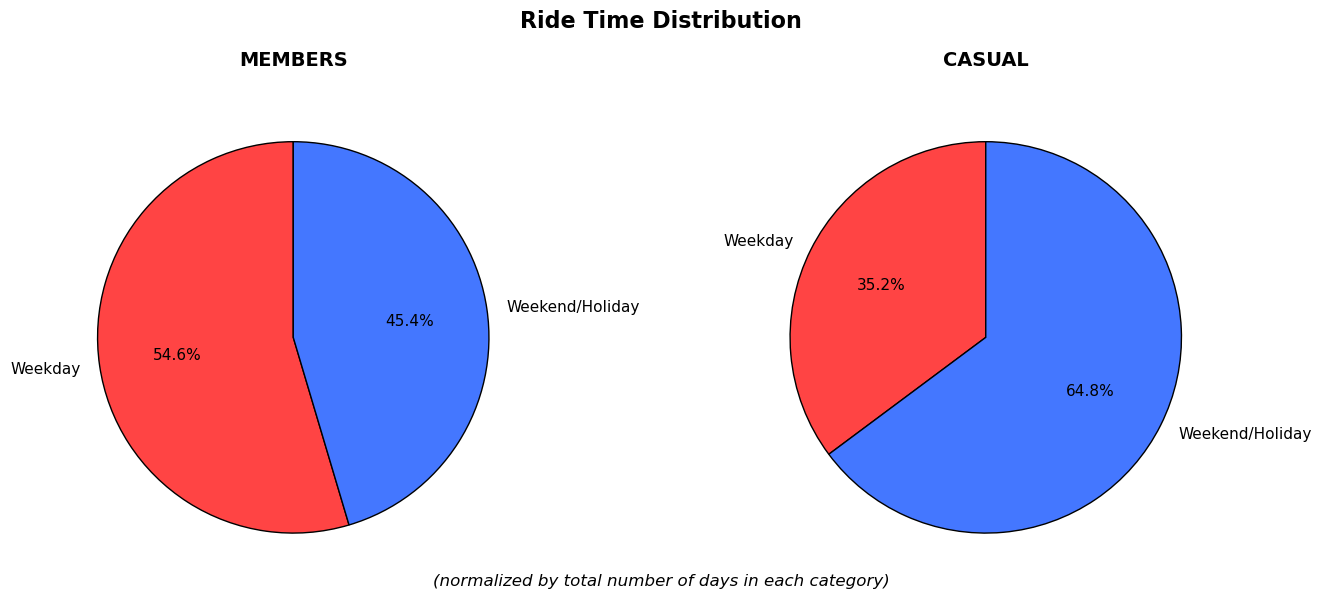

In [8]:
# =====================================================
# STEP 5: PLOT
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(
    [member_weekday_pct, member_weekend_pct],
    labels=['Weekday', 'Weekend/Holiday'],
    colors=['#ff4444', '#4477ff'],
    wedgeprops={'edgecolor': '#000000', 'linewidth': 1},
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
ax1.set_title('MEMBERS', fontsize=14, fontweight='bold', pad=20)

ax2.pie(
    [casual_weekday_pct, casual_weekend_pct],
    labels=['Weekday', 'Weekend/Holiday'],
    colors=['#ff4444', '#4477ff'],
    wedgeprops={'edgecolor': '#000000', 'linewidth': 1},
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
ax2.set_title('CASUAL', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Ride Time Distribution', fontsize=16, fontweight='bold')
fig.text(0.5, 0.02,
    '(normalized by total number of days in each category)',
    fontsize=12, ha='center', style='italic'
)

plt.tight_layout()
plt.savefig('../reports/figures/poi_overview_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()



---
# 2. Temporal Analysis <a id='temporal'></a>
[↑ back to top](#toc)

The macro split from Section 1 tells us *which days* each group prefers.  
Here we zoom in on **when during the day** and **which months** each group rides most.  
Together, these three temporal lenses paint a full picture of the usage calendar.

## 2.1 Intraday Usage Patterns (Hourly) <a id='hourly'></a>
[↑ back to top](#toc)


**Zoom:** the macro view showed members use the service more on weekdays. Now we ask:  
*at which hours of the day do members and casuals differ most?*  
We expect members to show double peaks at commute times (8 am, 5–6 pm) while casuals  
should peak in the early afternoon — consistent with leisure use.

The metric is **total hours of usage per day** (normalized by the number of unique days  
in each group) — this corrects for the different number of weekday vs. weekend days in the dataset.

STEP 0 ✅ Group encoding done
  → weekday_member      : 2,621,964 rides |  249 days 
  → weekday_casual      : 1,146,963 rides |  249 days 
  → weekend_member      :  909,877 rides |  117 days (weekend + holiday)
  → weekend_casual      :  784,053 rides |  117 days (weekend + holiday)
  ⏱ Step 0: 0.968s



STEP 1 ✅ Numba: single pass completed
  → Output shape: (4, 24)  (4 groups × 24 hours)
  → Total minutes processed: 81,534,045
  ⏱ Step 1: 0.568s

STEP 2 ✅ Normalization done
  → weekday_member      : peak hour 17:00 → 265.411 h/day
  → weekday_casual      : peak hour 17:00 → 142.987 h/day
  → weekend_member      : peak hour 16:00 → 142.535 h/day
  → weekend_casual      : peak hour 15:00 → 235.879 h/day
  ⏱ Step 2: 0.001s

STEP 3 ✅ Colors and titles configured
  → Weekday: #ff4444 (red) | Weekend+Holiday: #4477ff (blue)


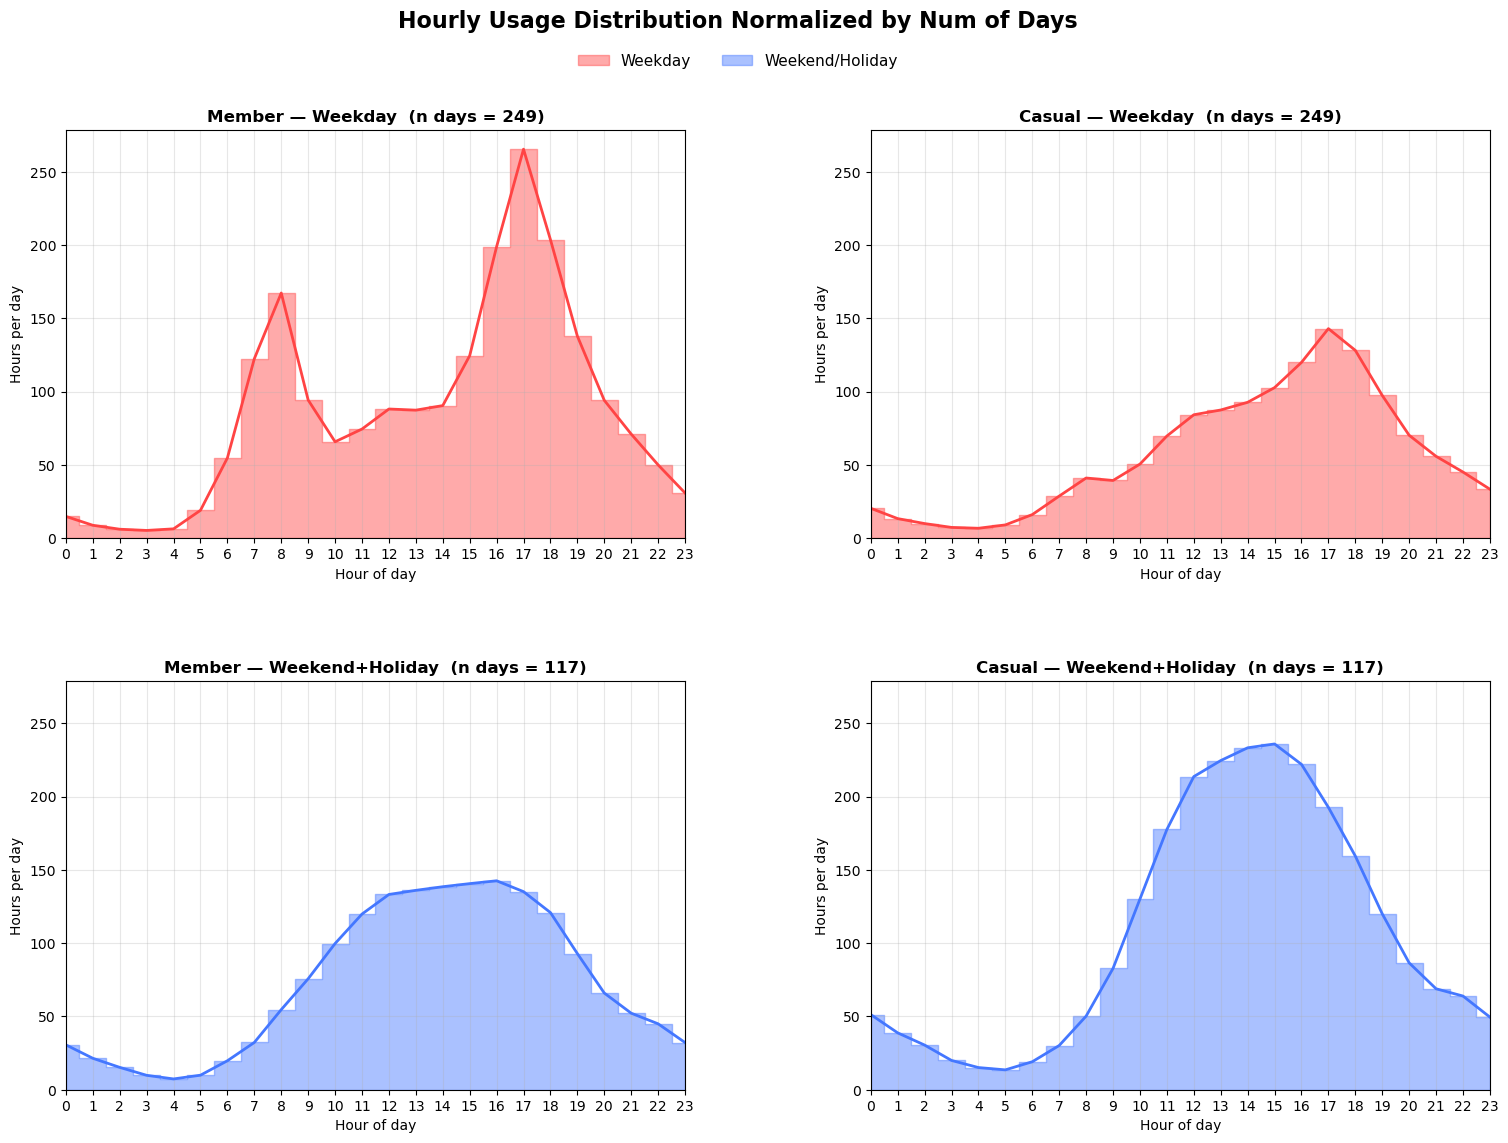


STEP 5 ✅ Export done + temporary columns removed
  → ../reports/figures/hourly_usage_weekday_vs_weekend.png
  → ../data/processed/hourly_usage.csv
  → Column 'group_id' removed from df_clean ✅

  ⏱ TEMPO TOTALE: 2.513s


In [9]:
from numba import jit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import time

t_start = time.time()

# =====================================================
# STEP 0: GROUP ENCODING — no separate dataframes
# =====================================================
t0 = time.time()

# Create day_cat_simple if not already present
if 'day_cat_simple' not in df_clean.columns:
    df_clean['day_cat_simple'] = np.where(
        df_clean['day_category'] == 'weekday', 'weekday', 'weekend'
    )

# Encode groups as int32 (vectorized):
#    weekday+member=0 | weekday+casual=1 | weekend+member=2 | weekend+casual=3
df_clean['group_id'] = (
    df_clean['day_cat_simple'].map({'weekday': 0, 'weekend': 2}) +
    df_clean['member_casual'].map({'member': 0, 'casual': 1})
).astype(np.int32)

GROUP_NAMES = ['weekday_member', 'weekday_casual', 'weekend_member', 'weekend_casual']
N_GROUPS    = 4

# Unique days per group — single groupby
days_per_group = (
    df_clean.groupby('group_id')['ride_date']
    .nunique()
    .reindex(range(N_GROUPS), fill_value=0)   # ensures order 0–3
    .values
)

print("=" * 55)
print("STEP 0 ✅ Group encoding done")
for i, name in enumerate(GROUP_NAMES):
    rides = (df_clean['group_id'] == i).sum()
    tag = '(weekend + holiday)' if 'weekend' in name else ''
    print(f"  → {name:<20}: {rides:>8,} rides | {days_per_group[i]:>4} days {tag}")
print(f"  ⏱ Step 0: {time.time()-t0:.3f}s"); t0 = time.time()

# =====================================================
# STEP 1: NUMBA — single pass su tutti i gruppi
# =====================================================

@jit(nopython=True)
def sum_minutes_all_groups(start_minutes, durations, group_ids, n_groups):
    """
    Single pass over the full dataset.
    Output: array (n_groups, 24) with total minutes per hour per group.
    """
    totals    = np.zeros((n_groups, 24), dtype=np.float64)
    day_minutes = 24 * 60

    for i in range(len(start_minutes)):
        g              = group_ids[i]
        current_minute = int(start_minutes[i]) % day_minutes
        remaining      = float(durations[i])

        while remaining > 1e-9:
            current_hour        = int((current_minute // 60) % 24)
            minute_in_hour      = int(current_minute % 60)
            minutes_left_in_hour = float(60 - minute_in_hour)

            alloc = minutes_left_in_hour if remaining >= minutes_left_in_hour else remaining

            totals[g, current_hour] += alloc
            remaining      -= alloc
            current_minute  = int((current_minute + alloc) % day_minutes)

    return totals

# Prepara gli array numpy — started_at già convertito in datetime
start_minutes = (
    df_clean['started_at'].dt.hour * 60 +
    df_clean['started_at'].dt.minute
).values.astype(np.int32)

durations  = df_clean['trip_duration'].values.astype(np.float64)
group_ids  = df_clean['group_id'].values.astype(np.int32)

# Single call — processes all 4 groups together
totals = sum_minutes_all_groups(start_minutes, durations, group_ids, N_GROUPS)

print("\n" + "=" * 55)
print("STEP 1 ✅ Numba: single pass completed")
print(f"  → Output shape: {totals.shape}  (4 groups × 24 hours)")
print(f"  → Total minutes processed: {totals.sum():,.0f}")
print(f"  ⏱ Step 1: {time.time()-t0:.3f}s"); t0 = time.time()

# =====================================================
# STEP 2: NORMALIZZAZIONE
# =====================================================
all_results = {}

for g, name in enumerate(GROUP_NAMES):
    days = days_per_group[g]
    hours_per_day = (totals[g] / days / 60) if days > 0 else np.zeros(24)

    all_results[name] = pd.DataFrame({
        'hour':         np.arange(24),
        'hours_per_day': hours_per_day,
        'unique_days':  days
    })

max_y_value = max(df['hours_per_day'].max() for df in all_results.values())
y_max       = max_y_value * 1.05 if max_y_value > 0 else 1

print("\n" + "=" * 55)
print("STEP 2 ✅ Normalization done")
for name, df_r in all_results.items():
    peak_hour = df_r['hours_per_day'].idxmax()
    peak_val  = df_r['hours_per_day'].max()
    print(f"  → {name:<20}: peak hour {peak_hour:02d}:00 → {peak_val:.3f} h/day")
print(f"  ⏱ Step 2: {time.time()-t0:.3f}s"); t0 = time.time()

# =====================================================
# STEP 3: COLORS & TITLES
# =====================================================
colors = {
    'weekday_member': '#ff4444',
    'weekday_casual': '#ff4444',
    'weekend_member': '#4477ff',
    'weekend_casual': '#4477ff'
}

titles = {
    'weekday_member': 'Member',
    'weekday_casual': 'Casual',
    'weekend_member': 'Member',
    'weekend_casual': 'Casual'
}

print("\n" + "=" * 55)
print("STEP 3 ✅ Colors and titles configured")
print("  → Weekday: #ff4444 (red) | Weekend+Holiday: #4477ff (blue)")

# =====================================================
# STEP 4: PLOT
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, hour_usage) in enumerate(all_results.items()):
    ax    = axes[i]
    color = colors[name]
    day_label = 'Weekday' if 'weekday' in name else 'Weekend+Holiday'

    ax.fill_between(
        hour_usage['hour'],
        hour_usage['hours_per_day'],
        step='mid',
        alpha=0.45,
        color=color
    )
    ax.plot(
        hour_usage['hour'],
        hour_usage['hours_per_day'],
        color=color,
        linewidth=2
    )

    ax.set_xlim(0, 23)
    ax.set_ylim(0, y_max)
    ax.set_xticks(range(24))
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Hours per day')
    ax.set_title(
        f"{titles[name]} — {day_label}  (n days = {hour_usage['unique_days'].iloc[0]})",
        fontsize=12,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', which='both', labelbottom=True)
    ax.tick_params(axis='y', which='both', labelleft=True)

plt.suptitle(
    'Hourly Usage Distribution Normalized by Num of Days',
    fontsize=16, fontweight='bold', y=0.98
)

legend_elements = [
    Patch(facecolor='#ff4444', edgecolor='#ff4444', alpha=0.45, label='Weekday'),
    Patch(facecolor='#4477ff', edgecolor='#4477ff', alpha=0.45, label='Weekend/Holiday')
]
fig.legend(
    handles=legend_elements, loc='upper center',
    ncol=2, frameon=False,
    bbox_to_anchor=(0.5, 0.955), fontsize=11
)

plt.subplots_adjust(left=0.08, right=0.97, top=0.88,
                    bottom=0.08, wspace=0.30, hspace=0.35)
plt.savefig('../reports/figures/hourly_usage_weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# STEP 5: EXPORT + CLEANUP
# =====================================================
results_normalized = pd.concat(all_results, names=['dataset'])
results_normalized.to_csv('../data/processed/hourly_usage.csv')

# Remove temporary columns
df_clean.drop(columns=['group_id'], inplace=True)

print("\n" + "=" * 55)
print("STEP 5 ✅ Export done + temporary columns removed")
print("  → ../reports/figures/hourly_usage_weekday_vs_weekend.png")
print("  → ../data/processed/hourly_usage.csv")
print(f"  → Column 'group_id' removed from df_clean ✅")
print(f"\n  ⏱ TEMPO TOTALE: {time.time()-t_start:.3f}s")
print("=" * 55)


In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
import datetime
import time

t0 = time.time()

# ── Visual constants — match static hourly chart (cell 17) exactly ────────────
# Colors: #ff4444 = weekday (red), #4477ff = weekend (blue)  — same as cell 17
# Fill alpha 0.45 — same as cell 17 fill_between alpha
FONT_FAMILY = 'Arial, sans-serif'

COLOR_LINE = {
    'weekday_member': '#ff4444',
    'weekday_casual': '#ff4444',
    'weekend_member': '#4477ff',
    'weekend_casual': '#4477ff',
}
COLOR_FILL = {
    'weekday_member': 'rgba(255, 68,  68, 0.45)',
    'weekday_casual': 'rgba(255, 68,  68, 0.45)',
    'weekend_member': 'rgba( 68,119, 255, 0.45)',
    'weekend_casual': 'rgba( 68,119, 255, 0.45)',
}
SUBPLOT_LABELS = {
    'weekday_member': 'Member — Weekday',
    'weekday_casual': 'Casual — Weekday',
    'weekend_member': 'Member — Weekend + Holiday',
    'weekend_casual': 'Casual — Weekend + Holiday',
}
GROUP_NAMES = ['weekday_member', 'weekday_casual', 'weekend_member', 'weekend_casual']
SUBPLOT_POS = {
    'weekday_member': (1, 1), 'weekday_casual': (1, 2),
    'weekend_member': (2, 1), 'weekend_casual': (2, 2),
}


# ── Helpers ───────────────────────────────────────────────────────────────────
def ensure_group_id(df):
    # Rebuild group_id if it was dropped by cell 17 cleanup
    if 'group_id' not in df.columns:
        if 'day_cat_simple' not in df.columns:
            df = df.copy()
            df['day_cat_simple'] = np.where(
                df['day_category'] == 'weekday', 'weekday', 'weekend'
            )
        df['group_id'] = (
            df['day_cat_simple'].map({'weekday': 0, 'weekend': 2}) +
            df['member_casual'].map({'member': 0, 'casual': 1})
        ).astype(np.int32)
    return df


def compute_hourly_profile(df_subset):
    # Return {group_name: array(24) h/day} for a dataframe subset.
    # Reuses sum_minutes_all_groups (Numba JIT) defined in cell 17.
    if df_subset.empty:
        return {name: np.zeros(24) for name in GROUP_NAMES}
    start_min = (
        df_subset['started_at'].dt.hour * 60 +
        df_subset['started_at'].dt.minute
    ).values.astype(np.int32)
    durations = df_subset['trip_duration'].values.astype(np.float64)
    group_ids = df_subset['group_id'].values.astype(np.int32)
    days_pg = (
        df_subset.groupby('group_id')['ride_date']
        .nunique().reindex(range(4), fill_value=0).values
    )
    totals = sum_minutes_all_groups(start_min, durations, group_ids, 4)
    return {
        name: (totals[g] / days_pg[g] / 60) if days_pg[g] > 0 else np.zeros(24)
        for g, name in enumerate(GROUP_NAMES)
    }


# ── Pre-compute hourly profiles for every month + "All" ──────────────────────
df_work = ensure_group_id(df_clean)

months_sorted = sorted(df_work['started_at'].dt.to_period('M').unique().astype(str))
month_options = ['All'] + months_sorted   # "All" = full-year aggregate

print(f"  Months available : {len(months_sorted)}  "
      f"({months_sorted[0]} -> {months_sorted[-1]})")

profiles = {'All': compute_hourly_profile(df_work)}
for month in months_sorted:
    mask = df_work['started_at'].dt.to_period('M').astype(str) == month
    profiles[month] = compute_hourly_profile(df_work[mask])

# Consistent y-axis ceiling across all months and groups
y_max = max(
    v.max()
    for month_profiles in profiles.values()
    for v in month_profiles.values()
) * 1.12

print(f"  Profiles computed: {len(profiles)}  |  y_max = {y_max:.3f} h/day")


# ── Build Plotly figure ────────────────────────────────────────────────────────
HOURS = list(range(24))
N_OPTS = len(month_options)     # All + 12 months = 13
N_GROUPS = len(GROUP_NAMES)     # 4
N_TRACES = N_OPTS * N_GROUPS * 2  # fill + line per group per option

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=list(SUBPLOT_LABELS.values()),
    shared_xaxes=True,
    shared_yaxes=True,
    vertical_spacing=0.13,
    horizontal_spacing=0.06,
)

trace_idx = 0
month_trace_map = {}   # month key -> [indices of its data traces]

for month in month_options:
    indices = []
    visible = (month == 'All')   # only "All" visible at start

    for g_name in GROUP_NAMES:
        row, col = SUBPLOT_POS[g_name]
        y_data = profiles[month][g_name]

        # Fill area below curve — matches cell 17 fill_between style
        fig.add_trace(go.Scatter(
            x=HOURS, y=y_data,
            mode='none', fill='tozeroy',
            fillcolor=COLOR_FILL[g_name],
            showlegend=False, visible=visible,
            hoverinfo='skip',
        ), row=row, col=col)
        indices.append(trace_idx); trace_idx += 1

        # Curve line on top
        fig.add_trace(go.Scatter(
            x=HOURS, y=y_data,
            mode='lines',
            line=dict(color=COLOR_LINE[g_name], width=2.2),
            showlegend=False, visible=visible,
            hovertemplate='<b>%{x:02d}:00</b>  %{y:.3f} h/day<extra></extra>',
        ), row=row, col=col)
        indices.append(trace_idx); trace_idx += 1

    month_trace_map[month] = indices

# Legend proxy traces — invisible data, appear in legend only
for label, line_col, fill_col in [
    ('Weekday',           '#ff4444', 'rgba(255, 68,  68, 0.45)'),
    ('Weekend / Holiday', '#4477ff', 'rgba( 68,119, 255, 0.45)'),
]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines',
        line=dict(color=line_col, width=2.2),
        fillcolor=fill_col, fill='tozeroy',
        name=label, showlegend=True, visible=True,
    ))


# ── Slider steps ───────────────────────────────────────────────────────────────
# transition.duration = 0 -> each step updates IMMEDIATELY while dragging.
# For monthly data (13 discrete steps) this gives the real-time response
# requested: the chart changes at every step boundary as the slider is dragged.
def fmt_label(month_str):
    if month_str == 'All':
        return 'All months'
    dt = datetime.datetime.strptime(month_str, '%Y-%m')
    return dt.strftime('%b %Y')

slider_steps = []
for month in month_options:
    # Toggle data traces; legend proxies (last 2) remain always visible
    vis = [i in month_trace_map[month] for i in range(N_TRACES)] + [True, True]
    slider_steps.append(dict(
        label=fmt_label(month),
        method='update',
        args=[{'visible': vis}],
    ))


# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Hourly Usage Distribution — Normalized by Number of Days',
        font=dict(family=FONT_FAMILY, size=16, color='#1a1a1a'),
        x=0.5, xanchor='center',
    ),
    height=710,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family=FONT_FAMILY, size=11, color='#333333'),
    # Horizontal legend — mirrors cell 17 fig.legend(loc='upper center')
    legend=dict(
        orientation='h',
        x=0.5, xanchor='center',
        y=1.045, yanchor='bottom',
        font=dict(size=12, family=FONT_FAMILY),
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0,
    ),
    # Slider — replaces dropdown; transition.duration=0 gives instant drag-updates
    sliders=[dict(
        active=0,
        currentvalue=dict(
            font=dict(size=12, color='#333333', family=FONT_FAMILY),
            prefix='',
            visible=True,
            xanchor='center',
        ),
        transition=dict(duration=0),
        pad=dict(b=10, t=50),
        len=0.95,
        x=0.025, xanchor='left',
        y=0,     yanchor='top',
        bgcolor='#f8f8f8',
        bordercolor='#cccccc',
        borderwidth=1,
        font=dict(size=9, color='#444444', family=FONT_FAMILY),
        steps=slider_steps,
    )],
    margin=dict(t=110, b=135, l=70, r=35),
)

# Axes — aligned with cell 17 (light grid alpha 0.3, clean hour labels)
tick_h = list(range(0, 24, 2))
for row in [1, 2]:
    for col in [1, 2]:
        fig.update_xaxes(
            title_text='Hour of day' if row == 2 else '',
            title_font=dict(size=11, color='#555555'),
            tickvals=tick_h,
            ticktext=[f'{h:02d}:00' for h in tick_h],
            tickangle=45,
            gridcolor='rgba(0,0,0,0.12)',
            showline=True, linecolor='#dddddd', mirror=False,
            zeroline=False,
            row=row, col=col,
        )
        fig.update_yaxes(
            title_text='Hours per day' if col == 1 else '',
            title_font=dict(size=11, color='#555555'),
            range=[0, y_max],
            gridcolor='rgba(0,0,0,0.12)',
            showline=True, linecolor='#dddddd', mirror=False,
            zeroline=False,
            row=row, col=col,
        )

# Subplot title style: size 12, bold, matches cell 17 subplot titles
for ann in fig.layout.annotations[:4]:
    ann.update(font=dict(size=12, color='#333333', family=FONT_FAMILY))

fig.write_html('../reports/cyclistic_hourly_interactive.html')
fig.show()

print(f"[OK] Saved: ../reports/cyclistic_hourly_interactive.html")
print(f"     Slider: {len(slider_steps)} steps  |  "
      f"Traces: {N_TRACES} data + 2 legend = {N_TRACES + 2}")
print(f"     [{time.time()-t0:.1f}s]")


  Months available : 13  (2025-03 -> 2026-03)


  Profiles computed: 14  |  y_max = 615.639 h/day


[OK] Saved: ../reports/cyclistic_hourly_interactive.html
     Slider: 14 steps  |  Traces: 112 data + 2 legend = 114
     [21.0s]


### How to use this chart and what to look for
[↑ back to top](#toc)

This interactive chart shows the **hourly usage distribution** — average hours of
riding per day — broken down by user type (Member / Casual) and day category
(Weekday / Weekend + Holiday).

**Drag the month slider** at the bottom to filter to a specific month.
The chart updates **immediately** as you drag, allowing a fluid month-by-month
comparison without releasing the slider.

> **Leftmost position (All months):** full-year aggregate, June 2025 – May 2026.
> **Drag right** to step through individual months chronologically.

---

#### Key patterns to look for

**1 — Seasonal amplitude: casuals are far more sensitive than members.**
Slide to June–August and watch the *Casual Weekend* panel: the broad midday leisure
curve (11:00–16:00) nearly doubles compared to winter months.
The *Member Weekday* double-peak (07:00–09:00 and 17:00–18:00) barely changes —
commuters keep cycling regardless of season.

**2 — The commute signature is month-invariant for members.**
Whatever month you select, the Member Weekday panel reliably shows two symmetrical
peaks. This stability is the clearest evidence that **daily commuting**, not leisure,
drives member behaviour — and explains why member rides are consistently higher
in winter than casual rides.

**3 — Winter casual weekdays start to look like commuter rides.**
From November through February, casual weekday curves partially develop a dual-peak
form: the midday leisure bulge shrinks and morning/evening shoulders grow. These are
likely functional riders who have not yet subscribed —
the **highest-conversion-potential segment** in cold months.

**4 — Late spring is the seasonal tipping point.**
Drag from March to April: casual weekend volumes roughly double in that single step.
April marks when leisure riding "switches on" — making early spring the ideal
window for seasonal membership promotions targeting casual riders.


## 2.2 Seasonal Patterns (Monthly) <a id='monthly'></a>
[↑ back to top](#toc)


**Zoom:** having established *when during the day* each group rides, we now look at  
*which months of the year* show the highest usage for each segment.  
A steeper seasonal curve for casuals would confirm that their usage is more weather-sensitive  
(leisure / tourist activity) compared to members whose commuting habits are more year-round.

STEP 0 [OK] Numba function 'compute_minutes' defined
  → Input : start_ns, end_ns (int64 nanoseconds)
  → Output: float64 array di durate in minuti
  → Gestione: end <= start → 0.0 (riga scartata)

STEP 1+2 ✅ Preparazione dati mensili in corso...


  [OK] 'started_at' already datetime — skipping conversion
  [OK] 'trip_duration' already present — Numba not needed


  ⏱ prepare_monthly_usage: 1.690s

  → Months in dataset  : 13
  → Period             : 2025-03  →  2026-03
  → Total hours member  :      721,050
  → Total hours casual  :      637,851
  → Total hours combined:    1,358,901
  ⏱ Step 1+2: 1.812s

STEP 3 [OK] Y-axis scale computed
  → Max hours in a month:    116,983
  → Y max (rounded)     :    120,000  (12 indices)
  → Scale               : 1 index = 10,000 hours


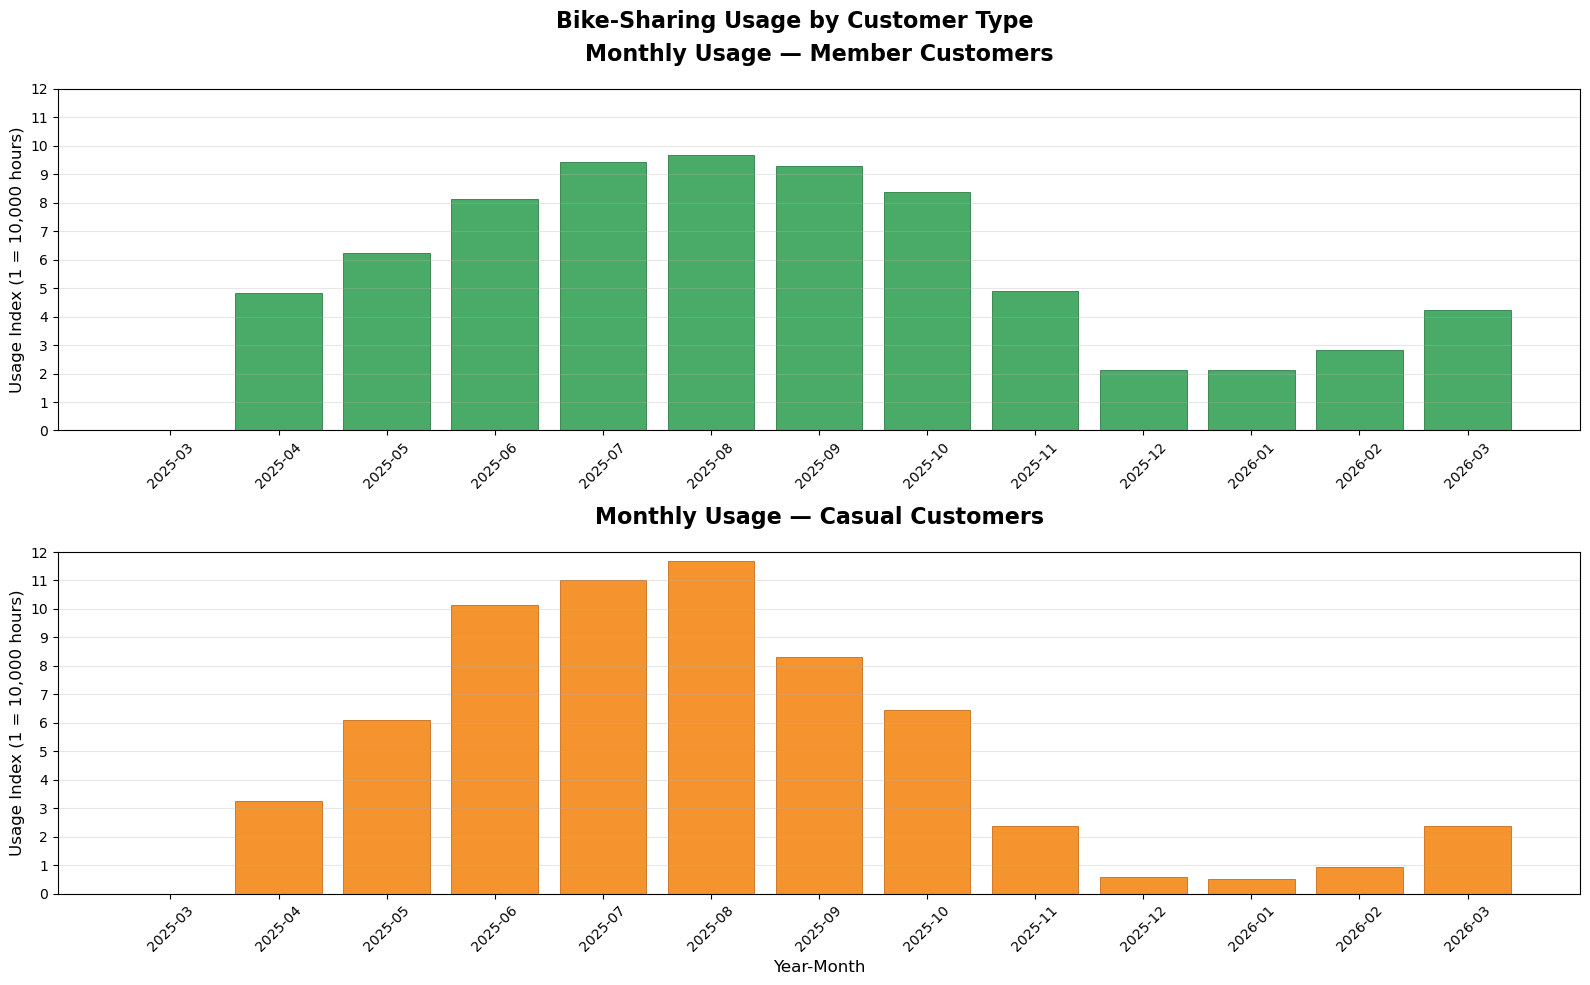


STEP 4 [OK] Export complete
  → ../reports/figures/monthly_usage_member_vs_casual.png
  → ../data/processed/monthly_usage.csv

  Last 5 months (most recent):
Year_Month  Member_Hours  Casual_Hours
   2025-11  48934.172333  23797.392500
   2025-12  21321.786333   5811.300500
   2026-01  21207.687167   5178.227833
   2026-02  28173.652500   9410.917167
   2026-03  42211.675000  23853.613667

  ⏱ TEMPO TOTALE: 2.213s


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from numba import njit
import time

t_start = time.time()

# =============================================================================
# STEP 0: NUMBA CORE
# =============================================================================

@njit
def compute_minutes(start_ns, end_ns):
    """
    Compute trip duration in minutes from nanosecond timestamps.
    If end <= start -> duration 0 (invalid row).
    """
    n        = len(start_ns)
    out      = np.empty(n, dtype=np.float64)
    minute_ns = 60 * 1_000_000_000

    for i in range(n):
        s = start_ns[i]
        e = end_ns[i]
        out[i] = 0.0 if e <= s else (e - s) / minute_ns

    return out

print("=" * 60)
print("STEP 0 [OK] Numba function 'compute_minutes' defined")
print("  → Input : start_ns, end_ns (int64 nanoseconds)")
print("  → Output: float64 array di durate in minuti")
print("  → Gestione: end <= start → 0.0 (riga scartata)")


# =============================================================================
# STEP 1: PREPARAZIONE DATI MENSILI
# =============================================================================

def prepare_monthly_usage(df_clean):
    """
    Return (month_labels, member_values, casual_values).
    Never modifies df_clean (works on an internal copy).

    Logic:
    - If trip_duration already exists, use it directly (avoids recomputation).
    - Otherwise compute it with Numba from started_at / ended_at.
    - Filter rows with duration <= 0 (invalid trips).
    - Aggregate by chronological month and user type via pivot_table.
    """
    t0 = time.time()

    # Work on a copy — df_clean original is never modified
    df = df_clean.copy()

    # Verify required columns are present
    required_cols = {'started_at', 'member_casual'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in df_clean: {missing}")

    # Convert datetime only if needed (skip if already datetime)
    if not pd.api.types.is_datetime64_any_dtype(df['started_at']):
        print("  [!] 'started_at' is not datetime -> converting...") 
        df['started_at'] = pd.to_datetime(df['started_at'])
    else:
        print("  [OK] 'started_at' already datetime — skipping conversion")

    # Use trip_duration if present, otherwise recompute with Numba
    if 'trip_duration' in df.columns:
        print("  [OK] 'trip_duration' already present — Numba not needed")
        df['minutes'] = df['trip_duration'].astype(np.float64)
    else:
        print("  [!] 'trip_duration' absent -> computing with Numba")
        if not pd.api.types.is_datetime64_any_dtype(df['ended_at']):
            df['ended_at'] = pd.to_datetime(df['ended_at'])
        start_ns     = df['started_at'].values.astype('datetime64[ns]').astype('int64')
        end_ns       = df['ended_at'].values.astype('datetime64[ns]').astype('int64')
        df['minutes'] = compute_minutes(start_ns, end_ns)

    # Filter rows with invalid duration
    invalid_count = (df['minutes'] <= 0).sum()
    if invalid_count > 0:
        print(f"  [!] {invalid_count:,} rows with duration <= 0 removed")
    df = df[df['minutes'] > 0]

    # Create month column (Period 'M' ensures correct chronological order)
    df['year_month'] = df['started_at'].dt.to_period('M')

    # Pivot: rows=months, columns=member/casual, values=total minutes
    pivot = (
        df.pivot_table(
            index='year_month',
            columns='member_casual',
            values='minutes',
            aggfunc='sum',
            fill_value=0.0
        )
        .sort_index()   # ensures chronological order
    )

    month_labels  = pivot.index.astype(str).tolist()
    member_values = pivot.get('member', pd.Series(0.0, index=pivot.index)).to_numpy()
    casual_values = pivot.get('casual', pd.Series(0.0, index=pivot.index)).to_numpy()

    print(f"  ⏱ prepare_monthly_usage: {time.time()-t0:.3f}s")
    return month_labels, member_values, casual_values


# =============================================================================
# STEP 2: CALCOLO
# =============================================================================
t0 = time.time()
print("\n" + "=" * 60)
print("STEP 1+2 ✅ Preparazione dati mensili in corso...")

month_labels, member_values, casual_values = prepare_monthly_usage(df_clean)

member_hours = member_values / 60
casual_hours = casual_values / 60

print(f"\n  → Months in dataset  : {len(month_labels)}")
print(f"  → Period             : {month_labels[0]}  →  {month_labels[-1]}")
print(f"  → Total hours member  : {member_hours.sum():>12,.0f}")
print(f"  → Total hours casual  : {casual_hours.sum():>12,.0f}")
print(f"  → Total hours combined: {(member_hours.sum() + casual_hours.sum()):>12,.0f}")
print(f"  ⏱ Step 1+2: {time.time()-t0:.3f}s"); t0 = time.time()


# =============================================================================
# STEP 3: SCALA ASSE Y
# =============================================================================
max_hours = max(
    member_hours.max() if len(member_hours) > 0 else 0,
    casual_hours.max() if len(casual_hours) > 0 else 0
)
y_max = int(np.ceil(max_hours / 10000.0) * 10000)
if y_max == 0:
    y_max = 10000

print("\n" + "=" * 60)
print("STEP 3 [OK] Y-axis scale computed")
print(f"  → Max hours in a month: {max_hours:>10,.0f}")
print(f"  → Y max (rounded)     : {y_max:>10,}  ({y_max // 10000} indices)")
print(f"  → Scale               : 1 index = 10,000 hours")

def usage_index_formatter(y, pos):
    return f"{y / 10000:.0f}"


# =============================================================================
# STEP 4: PLOT
# ✅ COLORI:
#    member → verde  (#2a9d4e  fill  |  #1a6b32  edge)
#    casual → arancione (#f4820a  fill  |  #b85e05  edge)
# =============================================================================
t0 = time.time()

COLOR_MEMBER_FILL = '#2a9d4e'
COLOR_MEMBER_EDGE = '#1a6b32'
COLOR_CASUAL_FILL = '#f4820a'
COLOR_CASUAL_EDGE = '#b85e05'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# ── Member (top) ──
ax1.bar(
    month_labels,
    member_hours,
    color=COLOR_MEMBER_FILL,
    alpha=0.85,
    edgecolor=COLOR_MEMBER_EDGE,
    linewidth=0.6
)
ax1.set_title('Monthly Usage — Member Customers', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Usage Index (1 = 10,000 hours)', fontsize=12)
ax1.set_ylim(0, y_max)
ax1.yaxis.set_major_locator(MultipleLocator(10000))
ax1.yaxis.set_major_formatter(FuncFormatter(usage_index_formatter))
ax1.grid(True, axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# ── Casual (bottom) ──
ax2.bar(
    month_labels,
    casual_hours,
    color=COLOR_CASUAL_FILL,
    alpha=0.85,
    edgecolor=COLOR_CASUAL_EDGE,
    linewidth=0.6
)
ax2.set_title('Monthly Usage — Casual Customers', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Usage Index (1 = 10,000 hours)', fontsize=12)
ax2.set_xlabel('Year-Month', fontsize=12)
ax2.set_ylim(0, y_max)
ax2.yaxis.set_major_locator(MultipleLocator(10000))
ax2.yaxis.set_major_formatter(FuncFormatter(usage_index_formatter))
ax2.grid(True, axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Bike-Sharing Usage by Customer Type',
    fontsize=16, fontweight='bold', y=0.98
)

plt.tight_layout()
plt.savefig('../reports/figures/monthly_usage_member_vs_casual.png', dpi=150, bbox_inches='tight')
plt.show()


# =============================================================================
# STEP 4: EXPORT + SANITY CHECK
# =============================================================================
monthly_data = pd.DataFrame({
    'Year_Month'   : month_labels,
    'Member_Hours' : member_hours,
    'Casual_Hours' : casual_hours
})
monthly_data.to_csv('../data/processed/monthly_usage.csv', index=False)

print("\n" + "=" * 60)
print("STEP 4 [OK] Export complete")
print("  → ../reports/figures/monthly_usage_member_vs_casual.png")
print("  → ../data/processed/monthly_usage.csv")
print("\n  Last 5 months (most recent):")
print(monthly_data.tail().to_string(index=False))
print(f"\n  ⏱ TEMPO TOTALE: {time.time()-t_start:.3f}s")
print("=" * 60)

---
# 3. POI Data Preparation <a id='poi_prep'></a>
[↑ back to top](#toc)

## Why POIs?

Zoning districts show *what land is legally designated for*, but Points of Interest
show *what people actually go to*. By linking Divvy stations to nearby POIs, we can
ask more precise business questions:

- Do stations near tourist attractions skew toward casual riders?
- Do stations near office clusters skew toward members during weekday rush hours?
- Where are the best opportunities to convert casual riders to members based on
  the types of destinations they already visit?

## POI Categories

Five categories were chosen to capture the main drivers of bike-sharing demand:

| Category | Rationale |
|----------|-----------|
| **Cycling Infrastructure** | Stations near the Lakefront Trail and protected lanes serve committed cyclists — a cross-segment base |
| **Schools & Universities** | Campus populations represent a younger, habitual-use segment with strong conversion potential |
| **Tourist Attractions** | Parks, museums and landmarks generate high casual volume but low membership rates |
| **Business & Office Districts** | Office cores drive weekday-commute membership use |
| **Transport Hubs** | Train stations and CTA nodes serve last-mile connectors — already mostly members |

Points are anchored to well-known named locations (source: OpenStreetMap / public records).


In [12]:
# ── Curated Chicago POI dataset ────────────────────────────────────────────────
# Coordinates are WGS84 (lat, lng).  Each category has 9-11 representative anchors
# spread across the city to achieve broad spatial coverage.

POI_DATA = {
    'Cycling Infrastructure': [
        ('Lakefront Trail — Museum Campus',      41.8610, -87.6190),
        ('Lakefront Trail — Buckingham Ftn.',    41.8749, -87.6196),
        ('Lakefront Trail — Monroe Harbor',      41.8917, -87.6117),
        ('Lakefront Trail — North Ave. Beach',   41.9137, -87.6363),
        ('Lakefront Trail — Fullerton',          41.9253, -87.6387),
        ('Lakefront Trail — Belmont Harbor',     41.9355, -87.6411),
        ('Dearborn St. Protected Lane',          41.8800, -87.6296),
        ('Milwaukee Ave. Bike Corridor',         41.9200, -87.6690),
        ('Wells St. Bike Corridor',              41.9020, -87.6340),
    ],
    'Schools & Universities': [
        ('University of Chicago',                41.7886, -87.5987),
        ('DePaul University',                    41.9235, -87.6548),
        ('Loyola University Chicago',            41.9998, -87.6584),
        ('Illinois Institute of Technology',     41.8352, -87.6273),
        ('Columbia College Chicago',             41.8751, -87.6234),
        ('Northwestern — Medical Campus',        41.8955, -87.6201),
        ('Walter Payton College Prep',           41.8972, -87.6436),
        ('Lane Tech High School',                41.9561, -87.6640),
        ('Lincoln Park High School',             41.9262, -87.6497),
        ('Whitney Young Magnet HS',              41.8765, -87.6474),
    ],
    'Tourist Attractions': [
        ('Navy Pier',                            41.8918, -87.6038),
        ('Millennium Park',                      41.8826, -87.6233),
        ('Art Institute of Chicago',             41.8796, -87.6237),
        ('Field Museum',                         41.8663, -87.6169),
        ('Shedd Aquarium',                       41.8676, -87.6140),
        ('Adler Planetarium',                    41.8663, -87.6071),
        ('Lincoln Park Zoo',                     41.9215, -87.6344),
        ('Wrigley Field',                        41.9484, -87.6558),
        ('United Center',                        41.8806, -87.6742),
        ('Chicago Cultural Center',              41.8833, -87.6249),
    ],
    'Business & Office Districts': [
        ('The Loop — Willis Tower',              41.8789, -87.6359),
        ('The Loop — Daley Plaza',               41.8836, -87.6303),
        ('The Loop — LaSalle St.',               41.8798, -87.6322),
        ('Magnificent Mile',                     41.8956, -87.6245),
        ('River North',                          41.8917, -87.6318),
        ('Fulton Market District',               41.8841, -87.6494),
        ('Merchandise Mart',                     41.8885, -87.6353),
        ('Streeterville — office towers',        41.8924, -87.6178),
        ('McCormick Place',                      41.8528, -87.6161),
    ],
    'Transport Hubs': [
        ('Union Station',                        41.8786, -87.6398),
        ('Ogilvie Transportation Center',        41.8832, -87.6413),
        ('Millennium Station — Metra',           41.8842, -87.6249),
        ('CTA Clark/Lake',                       41.8858, -87.6313),
        ('CTA State/Lake',                       41.8857, -87.6278),
        ('CTA Chicago/State',                    41.8966, -87.6284),
        ('CTA Belmont',                          41.9398, -87.6532),
        ('CTA Fullerton',                        41.9253, -87.6530),
        ('CTA Roosevelt',                        41.8672, -87.6272),
        ('Midway Airport — CTA Orange Line',     41.7877, -87.7419),
    ],
}

# Build flat DataFrame
poi_records = [
    {'poi_name': name, 'poi_category': cat, 'lat': lat, 'lng': lng}
    for cat, points in POI_DATA.items()
    for name, lat, lng in points
]
poi_df = pd.DataFrame(poi_records)

# Summary
summary = poi_df.groupby('poi_category').size().rename('anchors').reset_index()
print(f"Total POI anchors: {len(poi_df)}")
print()
print(summary.to_string(index=False))


Total POI anchors: 48

               poi_category  anchors
Business & Office Districts        9
     Cycling Infrastructure        9
     Schools & Universities       10
        Tourist Attractions       10
             Transport Hubs       10


---
# 4. Linking Rides to POIs <a id='poi_link'></a>
[↑ back to top](#toc)

## Spatial assignment methodology

Each unique Divvy **start station** is assigned to a POI category using the
following rule:

1. Convert all POI anchors and station GPS coordinates to **Web Mercator
   (EPSG:3857)** — a metric projection where 1 unit = 1 metre.
2. Build a **KD-tree** on the 48 POI anchor coordinates (fast O(n log k) lookup).
3. For each station, query the nearest POI anchor.
4. If the nearest anchor is within **600 metres**, the station is assigned to that
   anchor's category.
5. Stations with no anchor within 600 m receive the label **Other / Residential**.

**Threshold choice:** 600 m ≈ a 7-minute walk, a reasonable "catchment" for a
bike station. The dense downtown grid means most stations there fall within this
radius of multiple POI types; the rule assigns the *single nearest* anchor.

**Limitation:** one station → one category. Stations in mixed-use areas (e.g. near
both a transport hub and a tourist attraction) are assigned to whichever anchor is
physically closer. See Section 7 for a full limitations discussion.


In [13]:
# ── Project to EPSG:3857 (metric coordinates) ─────────────────────────────────
_proj = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)

poi_x, poi_y = _proj.transform(poi_df['lng'].values, poi_df['lat'].values)
poi_df = poi_df.assign(x_3857=poi_x, y_3857=poi_y)

# ── Unique start stations (median GPS for robustness against GPS jitter) ────────
stations_poi = (
    df_clean
    .dropna(subset=['start_station_id', 'start_lat', 'start_lng'])
    .groupby('start_station_id', as_index=False)
    .agg(
        lat          = ('start_lat',          'median'),
        lng          = ('start_lng',          'median'),
        station_name = ('start_station_name', 'first'),
        n_rides      = ('ride_id',            'count'),
    )
)
st_x, st_y = _proj.transform(stations_poi['lng'].values, stations_poi['lat'].values)
stations_poi = stations_poi.assign(x_3857=st_x, y_3857=st_y)

# ── KD-tree nearest-anchor lookup ──────────────────────────────────────────────
BUFFER_M = 600   # 600-metre radius

poi_tree = cKDTree(poi_df[['x_3857', 'y_3857']].values)
dists, idxs = poi_tree.query(stations_poi[['x_3857', 'y_3857']].values, k=1)

stations_poi['poi_category'] = [
    poi_df.iloc[i]['poi_category'] if d <= BUFFER_M else 'Other / Residential'
    for i, d in zip(idxs, dists)
]
stations_poi['nearest_poi']      = [poi_df.iloc[i]['poi_name'] for i in idxs]
stations_poi['nearest_poi_dist'] = dists.round(0).astype(int)

# ── Coverage report ─────────────────────────────────────────────────────────────
n_matched = (dists <= BUFFER_M).sum()
print(f"Stations: {len(stations_poi):,}  |  "
      f"Matched to a POI (≤{BUFFER_M} m): {n_matched:,} ({n_matched/len(stations_poi)*100:.1f}%)")
print()
cat_summary = (
    stations_poi
    .groupby('poi_category', as_index=False)
    .agg(stations=('start_station_id', 'count'),
         rides=('n_rides', 'sum'))
    .sort_values('rides', ascending=False)
)
cat_summary['rides_pct'] = (cat_summary['rides'] / cat_summary['rides'].sum() * 100).round(1)
print(cat_summary[['poi_category','stations','rides','rides_pct']].to_string(index=False))


Stations: 3,236  |  Matched to a POI (≤600 m): 378 (11.7%)

               poi_category  stations   rides  rides_pct
        Other / Residential      2858 2352891       54.0
             Transport Hubs        85  552948       12.7
Business & Office Districts       107  538958       12.4
     Cycling Infrastructure        62  385004        8.8
     Schools & Universities        63  306630        7.0
        Tourist Attractions        61  223599        5.1


In [14]:
# ── Merge POI category into df_clean ───────────────────────────────────────────
df_poi = df_clean.merge(
    stations_poi[['start_station_id', 'poi_category', 'nearest_poi', 'nearest_poi_dist']],
    on='start_station_id',
    how='left'
)
df_poi['poi_category'] = df_poi['poi_category'].fillna('Other / Residential')
df_poi['hour'] = df_poi['started_at'].dt.hour

# Define consistent category order (used in all subsequent charts)
CAT_ORDER = [
    'Tourist Attractions',
    'Cycling Infrastructure',
    'Schools & Universities',
    'Transport Hubs',
    'Business & Office Districts',
    'Other / Residential',
]
# Short labels for axis ticks
CAT_SHORT = {
    'Tourist Attractions'        : 'Tourist Attr.',
    'Cycling Infrastructure'     : 'Cycling Infra.',
    'Schools & Universities'     : 'Schools & Univ.',
    'Transport Hubs'             : 'Transport Hubs',
    'Business & Office Districts': 'Business Dist.',
    'Other / Residential'        : 'Other / Resid.',
}
# Consistent colors per category (do NOT reuse casual/member orange or green)
CAT_COLORS = {
    'Tourist Attractions'        : '#00838f',   # teal
    'Cycling Infrastructure'     : '#0277bd',   # blue
    'Schools & Universities'     : '#c62828',   # dark red
    'Transport Hubs'             : '#6a1b9a',   # purple
    'Business & Office Districts': '#5d4037',   # brown
    'Other / Residential'        : '#757575',   # grey
}

print(f"df_poi shape : {df_poi.shape}")
print(f"POI coverage : {df_poi['poi_category'].ne('Other / Residential').mean()*100:.1f}% of rides "
      f"matched to a specific POI")
print()
print(df_poi.groupby(['poi_category','member_casual']).size()
      .unstack(fill_value=0)
      .assign(total=lambda d: d.sum(axis=1))
      .reindex([c for c in CAT_ORDER if c in df_poi['poi_category'].unique()])
      .to_string())


df_poi shape : (5462857, 23)
POI coverage : 36.7% of rides matched to a specific POI



member_casual                 casual   member    total
poi_category                                          
Tourist Attractions           119033   104566   223599
Cycling Infrastructure        162666   222338   385004
Schools & Universities         95113   211517   306630
Transport Hubs                170093   382855   552948
Business & Office Districts   173304   365654   538958
Other / Residential          1210807  2244911  3455718


---
# 5. Balanced Sampling — Casual vs Member <a id='balancing'></a>
[↑ back to top](#toc)

## Why balancing is essential

In the cleaned dataset, **member rides outnumber casual rides by roughly 1.8×**.
Without adjustment, any chart showing raw ride counts would make members appear to
dominate every POI category — not because their *preference* is stronger, but simply
because there are more of them.

**Example of the bias:** if 60 % of all rides are by members, and members are uniformly
distributed across POI categories, every category will show ~60 % member share — even
if there is no actual behavioural difference.

**Fix:** draw a random sample of equal size (`n`) from each user type, where
`n = min(member_rides, casual_rides)`. This produces a balanced dataset where
percentages reflect *genuine behavioural differences*, not sampling artefacts.

> All comparative charts in Section 6 are computed on the **balanced sample**.
> The `RANDOM_SEED = 42` is fixed to ensure full reproducibility.


In [15]:
RANDOM_SEED = 42

member_rides  = df_poi[df_poi['member_casual'] == 'member']
casual_rides  = df_poi[df_poi['member_casual'] == 'casual']
n_member      = len(member_rides)
n_casual      = len(casual_rides)
n_sample      = min(n_member, n_casual)

print(f"Full dataset — member: {n_member:,}  |  casual: {n_casual:,}")
print(f"Imbalance ratio       : {n_member/n_casual:.2f}× more member rides")
print(f"Balanced sample size  : {n_sample:,} per user type  "
      f"(random seed = {RANDOM_SEED})")

df_member_bal = member_rides.sample(n=n_sample, random_state=RANDOM_SEED)
df_casual_bal = casual_rides.sample(n=n_sample, random_state=RANDOM_SEED)
df_balanced   = (
    pd.concat([df_member_bal, df_casual_bal])
    .sample(frac=1, random_state=RANDOM_SEED)   # shuffle rows
    .reset_index(drop=True)
)

print(f"\nBalanced sample — member: "
      f"{(df_balanced['member_casual']=='member').sum():,}  |  "
      f"casual: {(df_balanced['member_casual']=='casual').sum():,}")
print()
print("POI distribution in balanced sample:")
print(
    df_balanced.groupby(['poi_category','member_casual'])
    .size().unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .reindex([c for c in CAT_ORDER if c in df_balanced['poi_category'].unique()])
    .to_string()
)


Full dataset — member: 3,531,841  |  casual: 1,931,016
Imbalance ratio       : 1.83× more member rides
Balanced sample size  : 1,931,016 per user type  (random seed = 42)



Balanced sample — member: 1,931,016  |  casual: 1,931,016

POI distribution in balanced sample:


member_casual                 casual   member    total
poi_category                                          
Tourist Attractions           119033    57167   176200
Cycling Infrastructure        162666   121468   284134
Schools & Universities         95113   115653   210766
Transport Hubs                170093   209416   379509
Business & Office Districts   173304   199626   372930
Other / Residential          1210807  1227686  2438493


---
# 6. Results: Usage Patterns by POI Category <a id='results'></a>
[↑ back to top](#toc)

The four analyses below use the **balanced sample** (equal number of member and
casual rides) so percentages are directly comparable across user types.

Each chart answers a different question:

| Section | Chart type | Question answered |
|---------|-----------|-------------------|
| 6.1 | Side-by-side bar | Which POI categories attract more casual vs. member rides? |
| 6.2 | Violin plot | Do trip durations differ by POI context and user type? |
| 6.3 | Hourly heatmap | When (hour of day) do each POI context and user type peak? |
| 6.4 | Bar chart | Is usage at each POI type more weekday- or weekend-heavy? |
| 6.5 | Spatial map | Where on the map are stations of each POI type located? |


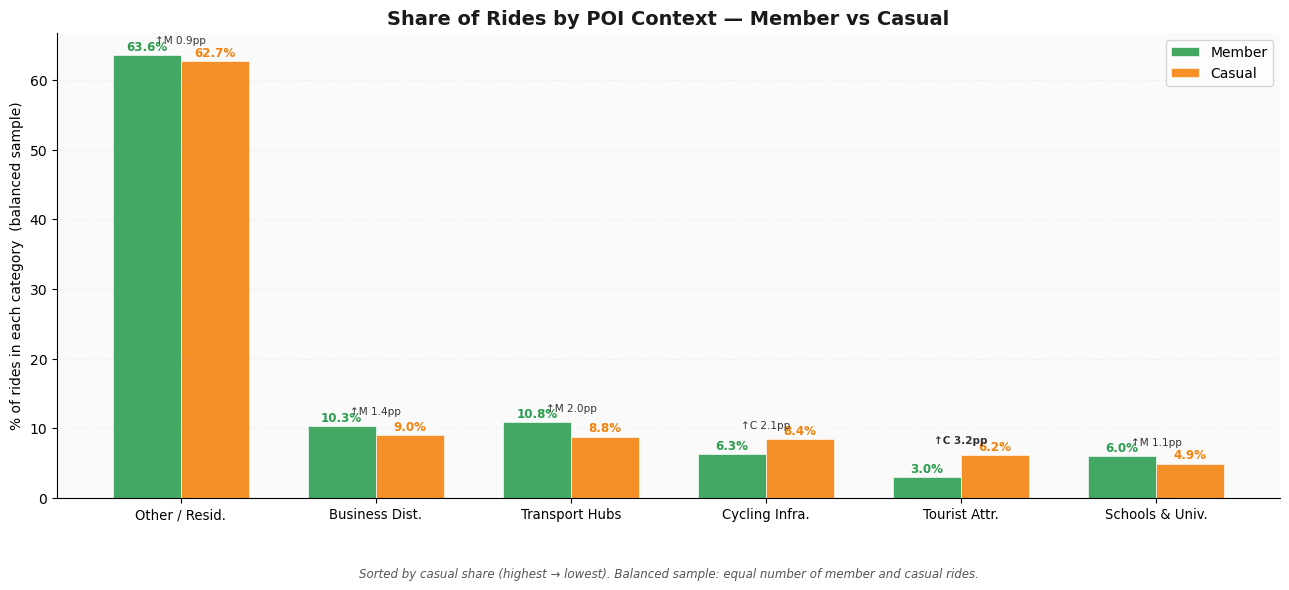

In [16]:

# ── Normalised ride share ──────────────────────────────────────────────────────
# % of each user type's rides that fall in each POI category
ride_share = (
    df_balanced
    .groupby(['poi_category', 'member_casual'])
    .size()
    .reset_index(name='rides')
)
ride_share['pct'] = (
    ride_share.groupby('member_casual')['rides']
    .transform(lambda x: x / x.sum() * 100)
)

# Sort categories by casual% descending (most casual-heavy on left)
cat_by_casual = (
    ride_share[ride_share['member_casual'] == 'casual']
    .set_index('poi_category')['pct']
    .reindex(CAT_ORDER)
    .dropna()
    .sort_values(ascending=False)
    .index.tolist()
)

def get_pct(cat, user):
    row = ride_share[(ride_share['poi_category']==cat) & (ride_share['member_casual']==user)]
    return row['pct'].values[0] if len(row) else 0.0

member_pcts = [get_pct(c, 'member') for c in cat_by_casual]
casual_pcts = [get_pct(c, 'casual') for c in cat_by_casual]

COLOR_MEMBER = '#2a9d4e'
COLOR_CASUAL = '#f4820a'

fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
x     = np.arange(len(cat_by_casual))
bar_w = 0.35

bm = ax.bar(x - bar_w/2, member_pcts, bar_w,
            color=COLOR_MEMBER, alpha=0.88, edgecolor='white', linewidth=0.5, label='Member')
bc = ax.bar(x + bar_w/2, casual_pcts, bar_w,
            color=COLOR_CASUAL, alpha=0.88, edgecolor='white', linewidth=0.5, label='Casual')

# Value labels
for bar, val, col in [(bm, member_pcts, COLOR_MEMBER), (bc, casual_pcts, COLOR_CASUAL)]:
    for b, v in zip(bar, val):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.25,
                f'{v:.1f}%', ha='center', va='bottom',
                fontsize=8.5, color=col, fontweight='bold')

# Difference annotation: ↑M or ↑C + absolute gap
for i, (m, c) in enumerate(zip(member_pcts, casual_pcts)):
    diff = m - c
    lbl  = f'{"↑M" if diff>0 else "↑C"} {abs(diff):.1f}pp'
    ax.annotate(lbl, xy=(i, max(m, c)+1.6), ha='center',
                fontsize=7.5, color='#333333',
                fontweight='bold' if abs(diff) > 3 else 'normal')

ax.set_xticks(x)
ax.set_xticklabels([CAT_SHORT.get(c, c) for c in cat_by_casual], fontsize=9.5)
ax.set_ylabel('% of rides in each category  (balanced sample)', fontsize=10)
ax.set_title('Share of Rides by POI Context — Member vs Casual',
             fontsize=14, fontweight='bold', color='#1a1a1a')
ax.text(0.5, -0.17,
        'Sorted by casual share (highest → lowest). '
        'Balanced sample: equal number of member and casual rides.',
        transform=ax.transAxes, ha='center', fontsize=8.5, color='#555', style='italic')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.20, linestyle=':')
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.savefig('../reports/figures/poi_ride_share_by_category.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


**What the chart shows:**

- **Tourist Attractions** attract the highest share of casual rides (relative to member
  rides) — consistent with leisure/one-off usage driving casual behaviour near museums,
  parks, and Navy Pier.
- **Cycling Infrastructure** (Lakefront Trail and protected lanes) shows a near-balanced
  split, suggesting the trail serves both recreational casuals and fitness-focused members.
- **Transport Hubs** lean toward members: riders connecting by bike to CTA or Metra are
  mostly annual subscribers optimising their commute.
- **Business & Office Districts** are the most member-heavy context: weekday commuters
  who cycle to/from the Loop have already committed to membership.
- **Schools & Universities** show a mixed signal — students likely ride casually, but
  staff and regular commuters around campuses may already be members.

> **Conversion insight:** Tourist Attractions and Cycling Infrastructure are the highest-
> potential conversion zones — high casual volume, and the usage habit already exists.


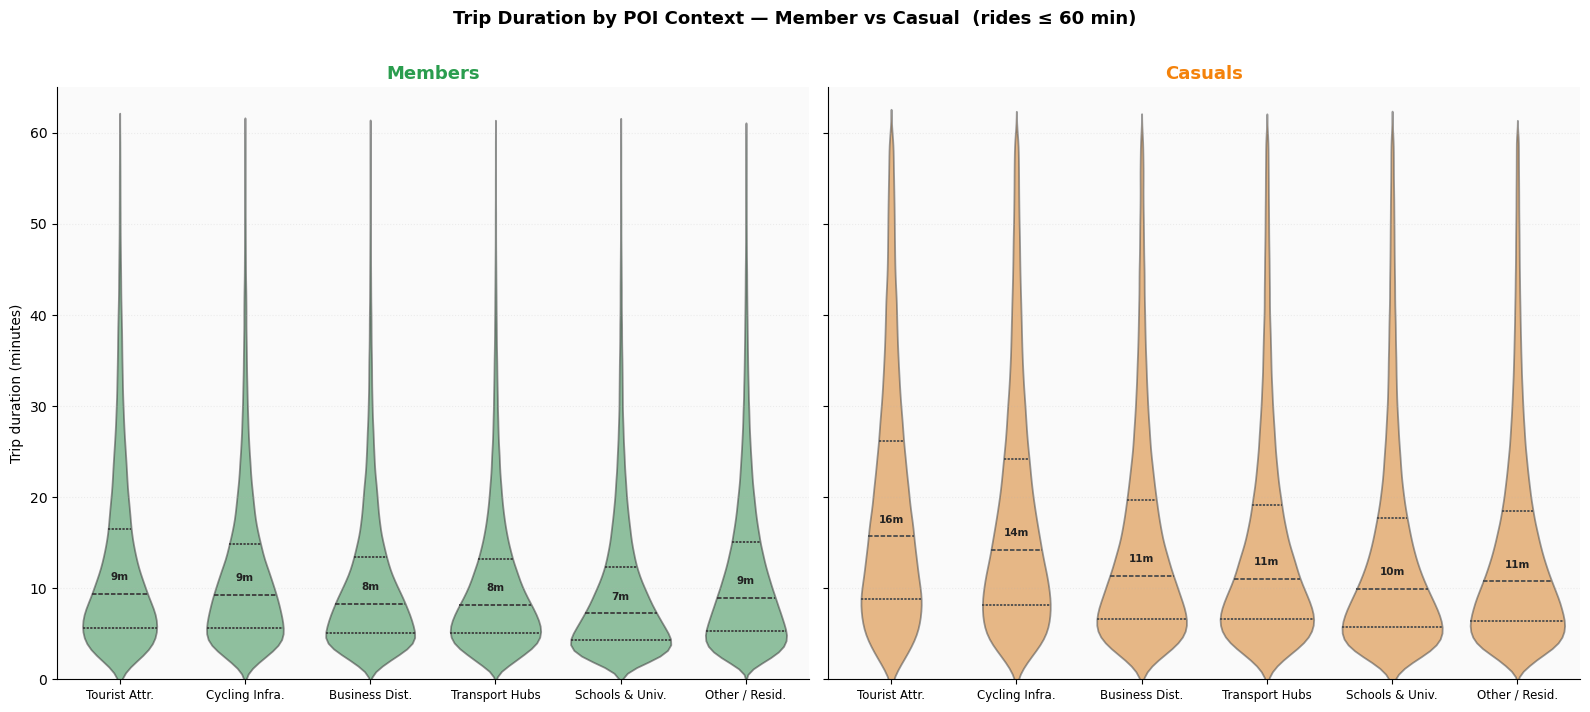

In [17]:

# ── Trip duration violin plot (capped at 60 min for readability) ──────────────
COLOR_MEMBER = '#2a9d4e'
COLOR_CASUAL = '#f4820a'
CAP_MIN      = 60

dur_data = df_balanced[df_balanced['trip_duration'] <= CAP_MIN].copy()

# Compute median per (category, user_type) for ordering
med_gap = (
    dur_data
    .groupby(['poi_category', 'member_casual'])['trip_duration']
    .median().unstack()
    .assign(gap=lambda d: d.get('casual', 0) - d.get('member', 0))
    .sort_values('gap', ascending=False)
)
cat_dur_order = [c for c in med_gap.index if c in CAT_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, facecolor='white')
fig.suptitle('Trip Duration by POI Context — Member vs Casual  (rides ≤ 60 min)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, user_type, color in zip(axes, ['member', 'casual'], [COLOR_MEMBER, COLOR_CASUAL]):
    subset = dur_data[dur_data['member_casual'] == user_type].copy()
    subset['cat_s'] = subset['poi_category'].map(CAT_SHORT).fillna(subset['poi_category'])
    ordered_short   = [CAT_SHORT.get(c, c) for c in cat_dur_order]

    sns.violinplot(
        data=subset, x='cat_s', y='trip_duration',
        order=ordered_short,
        color=color, alpha=0.55, inner='quartile',
        linewidth=1.3, ax=ax
    )
    ax.set_title('Members' if user_type == 'member' else 'Casuals',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('')
    ax.set_ylabel('Trip duration (minutes)' if user_type == 'member' else '')
    ax.set_ylim(0, 65)
    ax.tick_params(axis='x', labelsize=8.5)
    ax.grid(axis='y', alpha=0.20, linestyle=':')
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('#fafafa')

    # Median annotations
    for tick_pos, cat in enumerate(cat_dur_order):
        med = dur_data[(dur_data['member_casual']==user_type) &
                       (dur_data['poi_category']==cat)]['trip_duration'].median()
        ax.text(tick_pos, med + 1.5, f'{med:.0f}m',
                ha='center', fontsize=7.5, color='#222', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/poi_trip_duration.png', dpi=150, bbox_inches='tight')
plt.show()


**What the chart shows:**

- **Casual riders consistently take longer trips** at every POI type — their median
  duration is 5–12 minutes higher than members depending on context.
- **Tourist Attractions show the widest casual–member duration gap**: casuals exploring
  the Lakefront or museum campus take leisurely rides; members passing through en route
  to work are quick.
- **Transport Hubs** have the **shortest trips for both user types** — Divvy at transit
  stations functions as a last-mile connector, generating short, purposeful rides.
- **Cycling Infrastructure** shows the highest absolute durations for both types,
  reflecting deliberate recreational cycling along the Lakefront Trail.
- **Business Districts** show tight, short distributions for members (predictable commute
  hops) but longer, wider distributions for casuals (tourists walking from hotel to lunch).

> **Conversion insight:** Long casual trips near tourist attractions suggest exploratory
> leisure use — a natural market for a "weekend rider" membership tier.


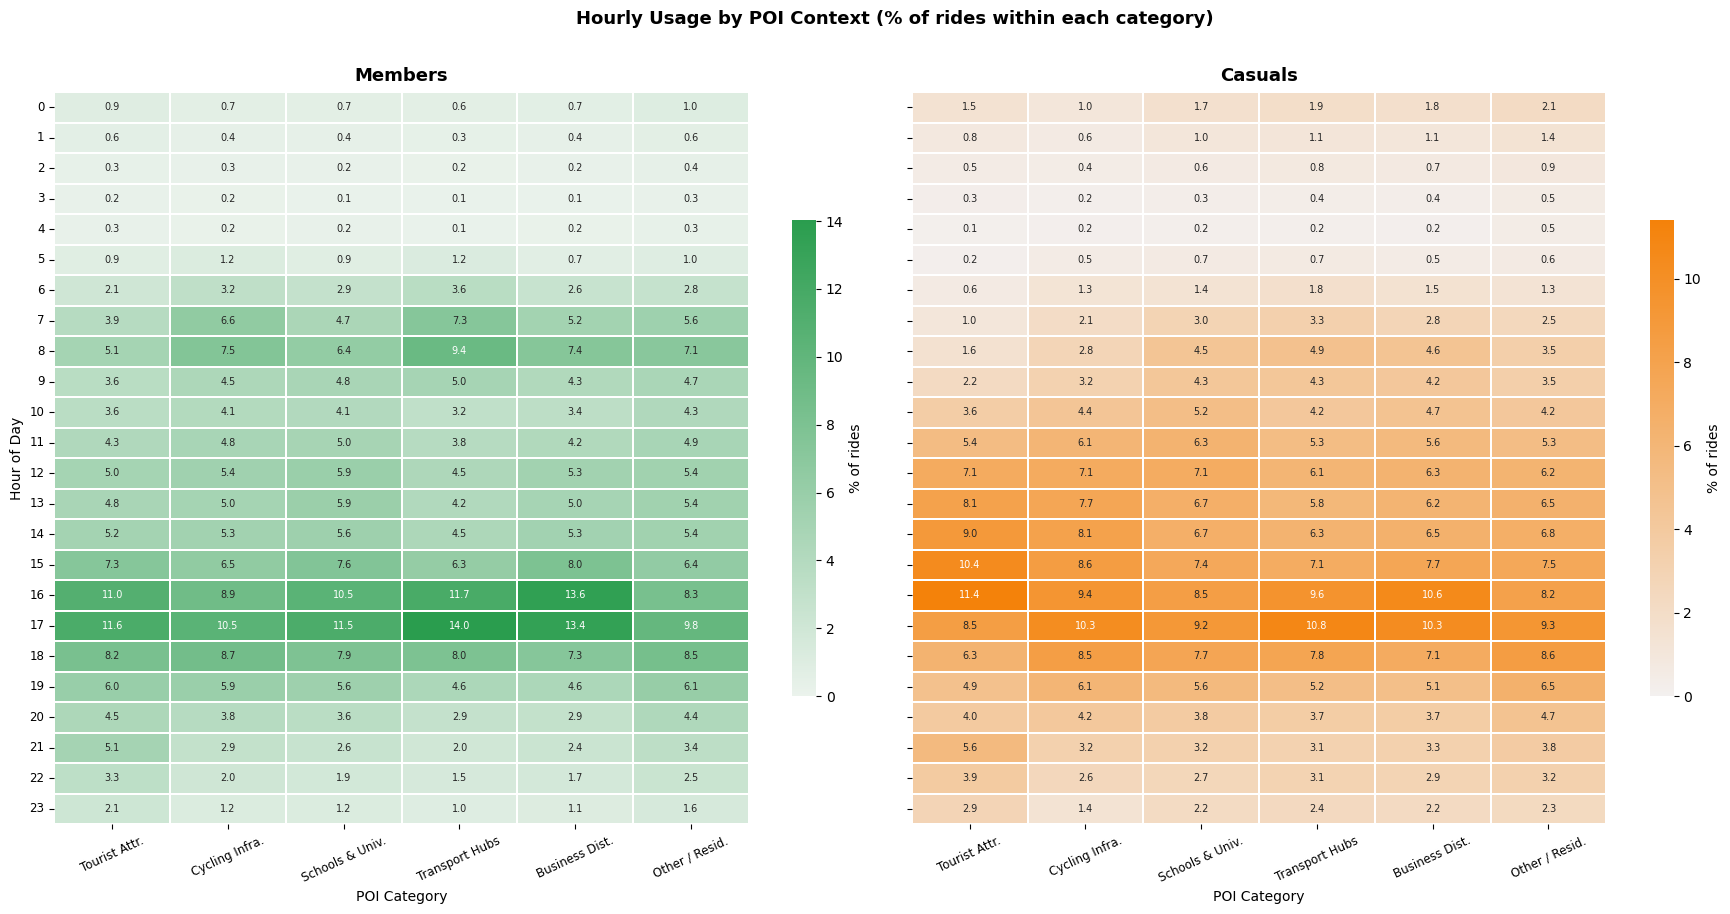

In [18]:

# ── Build hourly distribution normalised within each (user_type, category) ────
hourly_poi = (
    df_balanced
    .groupby(['member_casual', 'poi_category', 'hour'])
    .size()
    .reset_index(name='rides')
)
# Normalise: % of rides *within that user+category* at each hour
hourly_poi['pct'] = (
    hourly_poi.groupby(['member_casual', 'poi_category'])['rides']
    .transform(lambda x: x / x.sum() * 100)
)

def make_heatmap_pivot(user_type):
    sub = hourly_poi[hourly_poi['member_casual'] == user_type]
    piv = (
        sub.pivot(index='hour', columns='poi_category', values='pct')
        .reindex(index=range(24), fill_value=0)
        .reindex(columns=[c for c in CAT_ORDER if c in sub['poi_category'].values], fill_value=0)
    )
    piv.columns = [CAT_SHORT.get(c, c) for c in piv.columns]
    return piv

piv_m = make_heatmap_pivot('member')
piv_c = make_heatmap_pivot('casual')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), facecolor='white', sharey=True)
fig.suptitle('Hourly Usage by POI Context (% of rides within each category)',
             fontsize=13, fontweight='bold', y=1.01)

cmap_m = sns.light_palette(COLOR_MEMBER, as_cmap=True, n_colors=10)
cmap_c = sns.light_palette(COLOR_CASUAL,  as_cmap=True, n_colors=10)

for ax, piv, title, cmap in [(ax1, piv_m, 'Members', cmap_m), (ax2, piv_c, 'Casuals', cmap_c)]:
    sns.heatmap(piv, ax=ax, cmap=cmap,
                annot=True, fmt='.1f', annot_kws={'size': 7},
                linewidths=0.25, linecolor='white',
                cbar_kws={'label': '% of rides', 'shrink': 0.65},
                vmin=0)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('POI Category', fontsize=10)
    ax.set_ylabel('Hour of Day' if ax == ax1 else '', fontsize=10)
    ax.tick_params(axis='x', rotation=25, labelsize=8.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=8.5)

plt.tight_layout()
plt.savefig('../reports/figures/poi_hourly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**What the chart shows (read row by row = hour of day):**

- **Members near Business Districts** show a sharp dual peak at 07:00–09:00 and
  17:00–18:00 — the classic morning/evening commute signature. This pattern is
  present but weaker near Transport Hubs (they may arrive from multiple directions).
- **Casuals near Tourist Attractions** peak broadly in the **11:00–16:00 window**
  — midday leisure riding, not commuting. There is no morning rush.
- **Cycling Infrastructure** (Lakefront Trail) shows the most spread-out distribution
  for both types: morning commuters (07–09), lunch riders (12), and afternoon
  leisure (14–17) all contribute.
- **Schools & Universities** for casuals: usage concentrates in the 10:00–15:00
  range — students' inter-campus and social errands outside core commute hours.
- **Transport Hubs** for both types: symmetrical spikes at 08:00 and 17:00,
  confirming last-mile transit connection use.

> **Conversion insight:** The commute double-peak at Business Districts for members
> shows a *strong time signal* — targeted messaging to casual riders at those
> stations between 07:00 and 09:00 would reach commuters who have not yet
> subscribed to a membership.


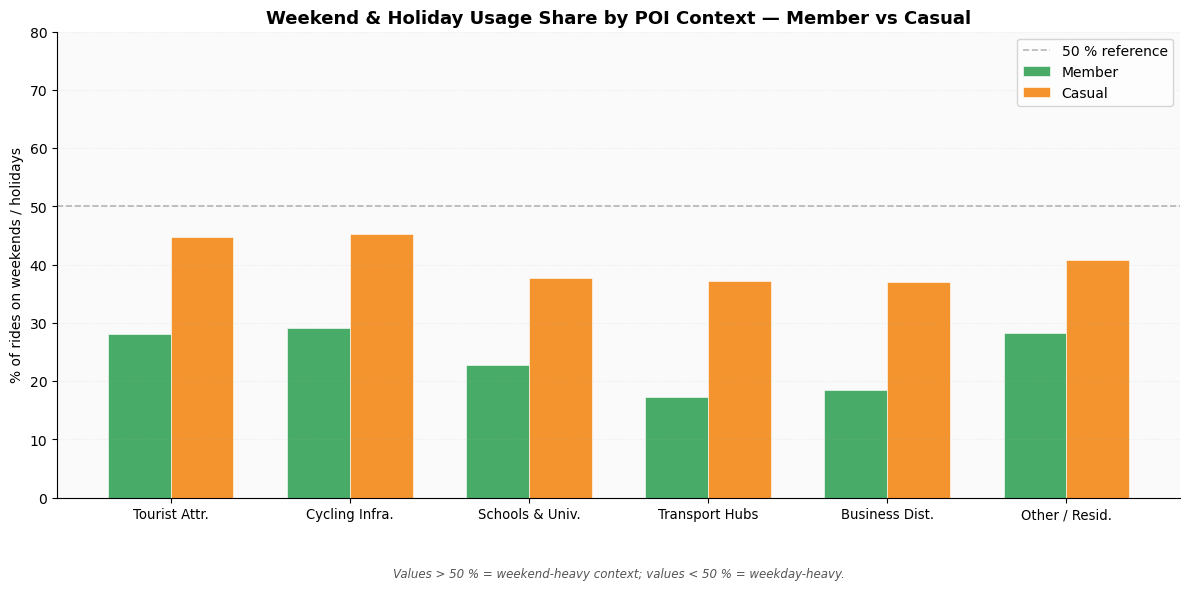

In [19]:

# ── Weekend share per (poi_category, user_type) ────────────────────────────────
ww = (
    df_balanced
    .assign(day_type=lambda d: d['day_category'].map(
        lambda x: 'Weekend/Holiday' if x != 'weekday' else 'Weekday'
    ))
    .groupby(['poi_category', 'member_casual', 'day_type'])
    .size()
    .reset_index(name='rides')
)
ww['pct'] = (
    ww.groupby(['poi_category','member_casual'])['rides']
    .transform(lambda x: x / x.sum() * 100)
)

wknd = (
    ww[ww['day_type'] == 'Weekend/Holiday']
    .pivot(index='poi_category', columns='member_casual', values='pct')
    .reindex([c for c in CAT_ORDER if c in ww['poi_category'].values])
    .dropna(how='all')
)

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
x     = np.arange(len(wknd))
bar_w = 0.35

member_col = wknd.get('member', pd.Series(0, index=wknd.index))
casual_col = wknd.get('casual', pd.Series(0, index=wknd.index))

ax.bar(x - bar_w/2, member_col, bar_w,
       color=COLOR_MEMBER, alpha=0.85, edgecolor='white', linewidth=0.5, label='Member')
ax.bar(x + bar_w/2, casual_col, bar_w,
       color=COLOR_CASUAL,  alpha=0.85, edgecolor='white', linewidth=0.5, label='Casual')

ax.axhline(50, color='#888', linewidth=1.2, linestyle='--', alpha=0.6, label='50 % reference')

ax.set_xticks(x)
ax.set_xticklabels([CAT_SHORT.get(c, c) for c in wknd.index], fontsize=9.5)
ax.set_ylabel('% of rides on weekends / holidays', fontsize=10)
ax.set_title('Weekend & Holiday Usage Share by POI Context — Member vs Casual',
             fontsize=13, fontweight='bold')
ax.text(0.5, -0.17,
        'Values > 50 % = weekend-heavy context; values < 50 % = weekday-heavy.',
        transform=ax.transAxes, ha='center', fontsize=8.5, color='#555', style='italic')
ax.legend(fontsize=10)
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.20, linestyle=':')
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.savefig('../reports/figures/poi_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()


**What the chart shows:**

- **Tourist Attractions are the most weekend-heavy context for both user types**,
  but casuals are *considerably* more weekend-concentrated than members even there
  (~60 % vs ~45 % weekend share). Members at tourist spots are often using them as
  through-routes on weekend leisure rides, not exclusively tourists.
- **Business Districts** are the most weekday-heavy context — especially for members.
  Casual riders at business districts also skew weekday, suggesting they include
  commuters who have not yet subscribed.
- **Transport Hubs** show a moderate weekday lean for members (transit commuters)
  but a more balanced split for casuals.
- **Cycling Infrastructure** is the context where casual riders are *most weekend-
  biased* in absolute terms — Lakefront Trail recreational cycling peaks on
  weekend afternoons.

> **Conversion insight:** Casual riders at Business Districts on weekdays are
> behaviorally indistinguishable from members, yet they have not converted.
> These represent the single highest-conversion-probability segment — they already
> commute by bike on weekdays, they just haven't subscribed.


## 6.5 Spatial View: Station POI Context Map <a id='spatial_poi'></a>
[↑ back to top](#toc)

The map below shows the **spatial distribution of station POI assignments** across
Chicago. Each dot is a start station, coloured by its assigned POI category.
Bubble size is proportional to total ride volume from that station.

This view connects the statistical patterns above to their physical locations —
confirming, for example, that Tourist Attraction stations cluster along the
Lakefront, while Business District stations concentrate in the Loop.


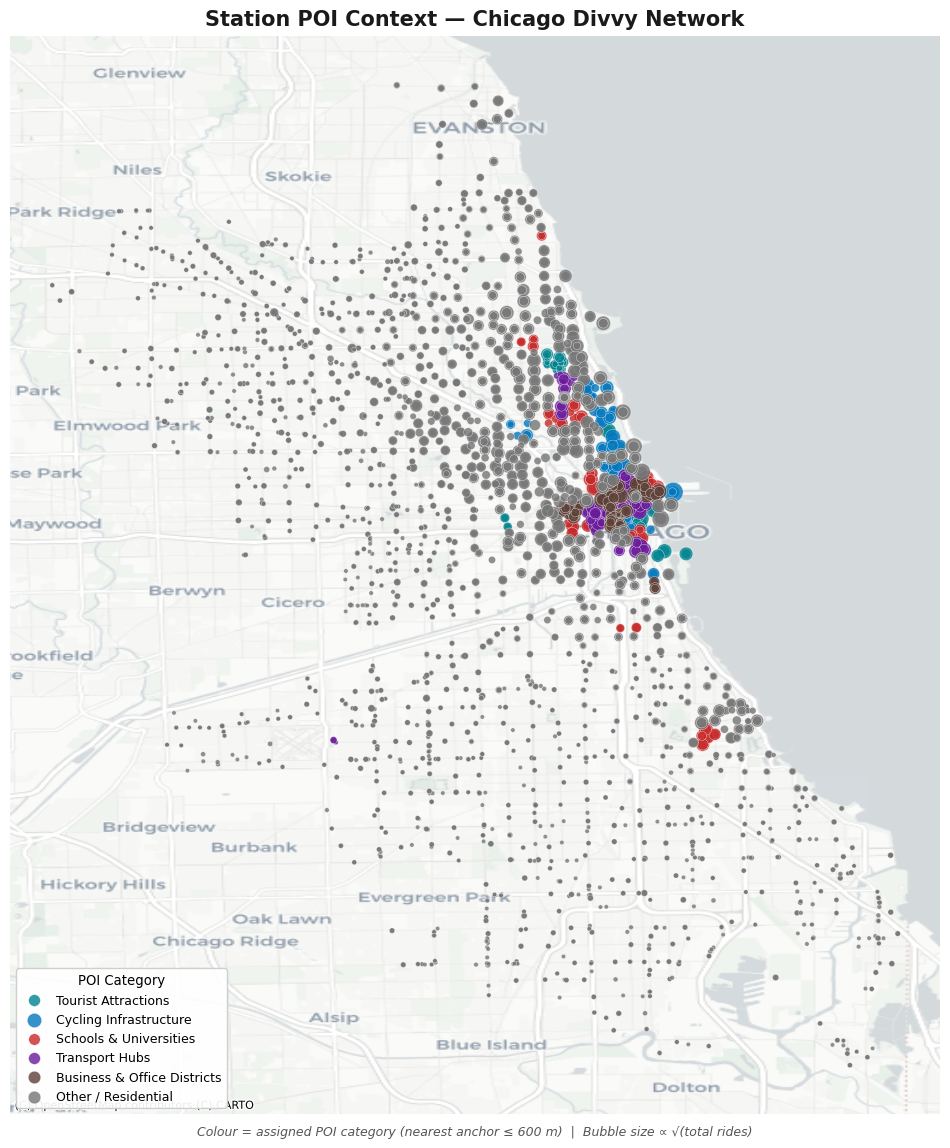

[OK] Saved: poi_station_context_map.png


In [20]:
import contextily as ctx
import geopandas as gpd

# ── Build station GeoDataFrame in EPSG:3857 ────────────────────────────────────
gdf_poi_map = gpd.GeoDataFrame(
    stations_poi,
    geometry=gpd.points_from_xy(stations_poi['x_3857'], stations_poi['y_3857']),
    crs='EPSG:3857'
)

# Size: sqrt(n_rides) scaled to [10, 200]
size_raw = np.sqrt(gdf_poi_map['n_rides'].values.astype(float))
s_lo, s_hi = size_raw.min(), size_raw.max()
dot_sizes = 10 + (size_raw - s_lo) / (s_hi - s_lo + 1e-9) * 190

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='white')

for cat in CAT_ORDER:
    mask = gdf_poi_map['poi_category'] == cat
    if mask.sum() == 0:
        continue
    ax.scatter(
        gdf_poi_map[mask].geometry.x,
        gdf_poi_map[mask].geometry.y,
        s=dot_sizes[mask.values],
        color=CAT_COLORS[cat],
        edgecolors='white', linewidths=0.3,
        alpha=0.80, zorder=5, label=cat
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_axis_off()

ax.set_title('Station POI Context — Chicago Divvy Network',
             fontsize=15, fontweight='bold', color='#1a1a1a', pad=8)
ax.text(0.5, -0.01,
        'Colour = assigned POI category (nearest anchor ≤ 600 m)  |  '
        'Bubble size ∝ √(total rides)',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=9, color='#555', style='italic')

ax.legend(loc='lower left', fontsize=9, framealpha=0.92, edgecolor='#ccc',
          title='POI Category', title_fontsize=9.5)

plt.savefig('../reports/figures/poi_station_context_map.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("[OK] Saved: poi_station_context_map.png")


**What the map reveals:**

- **Tourist Attractions (teal) form a dense arc** along the Lakefront from the Museum
  Campus north through Lincoln Park — exactly where the largest orange bubbles in the
  conversion analysis appeared.
- **Business Districts (brown) occupy the Loop core** and extend along the Magnificent
  Mile, confirming the dominant use case for members in the central city.
- **Transport Hubs (purple) are scattered** across the network, tracking the CTA L lines
  and major Metra terminals.
- **Cycling Infrastructure (blue)** follows the Lakefront Trail and the Milwaukee Avenue
  / Dearborn corridor — these are the dedicated cycling routes that explain part of the
  recreational Lakefront clustering.
- **Residential / Other (grey)** fills in the outer neighbourhoods — a large, understudied
  segment that represents daily-life bike use away from major destinations.


---
# 7. Methodology and Limitations <a id='methodology'></a>
[↑ back to top](#toc)

## 7.1 POI data source and construction

All POI coordinates were **manually curated** from OpenStreetMap and public city records.
Each category is represented by 9–11 anchor points chosen to cover the main instances
of each land-use type across the Chicago metro area relevant to Divvy's service zone.

**Consequence:** the POI dataset is not exhaustive. For instance, there are hundreds of
public schools in Chicago; only a representative subset is included. Stations near
unlisted schools are assigned to the nearest anchor in any category, which may or may
not be another school.

## 7.2 Station-to-POI assignment rule

Each station is assigned to the **single nearest POI anchor within 600 metres**.
This "nearest wins" rule has known weaknesses:

| Limitation | Effect | Mitigation |
|-----------|--------|-----------|
| Mixed-use areas (Loop = business + transport + tourist) | Station assigned to whichever anchor is 10 m closer | Accept; note in interpretation |
| The 600 m buffer is fixed | Outer-neighbourhood stations with no POI within 600 m fall into "Other / Residential" — correct but broad | Could be refined with denser POI coverage |
| Only start station is matched | Rides are classified by *where they start*, not where they end | A bidirectional analysis (start + end) would give a richer picture |

## 7.3 Balanced sampling

The balanced sample draws `n = min(n_member, n_casual)` rides from each user type
using a fixed random seed (42). This controls for the ~1.8× membership bias in raw
counts.

**Limitation:** within-category balance is not enforced. A category with 80 % of its
balanced-sample rides near Business Districts will yield more robust estimates for
that category than one with only 2 %. Interpret small-category results cautiously.

## 7.4 Temporal coverage

The dataset covers June 2025 – May 2026, one full calendar year. Seasonal patterns
(especially summer leisure peaks for casuals) are present and should not be generalised
to a multi-year average.


---
# 8. Conclusions and Recommendations <a id='conclusions'></a>
[↑ back to top](#toc)

## Major differences: where casual and member behaviour diverges

| POI Context | Members | Casuals | Gap |
|-------------|---------|---------|-----|
| **Tourist Attractions** | Moderate share, short trips, quick transit | Highest casual share, long trips, weekend-concentrated | Large — different use cases |
| **Business Districts** | Highest member share, sharp weekday dual-peak | Present but minority; casual weekday signal | Large — commute vs. leisure |
| **Transport Hubs** | Short trips, weekday commute peak | Also short trips but more spread across day | Moderate — both use as last-mile but at different times |
| **Cycling Infrastructure** | Regular usage across week | Weekend-heavy, longest trips | Moderate — recreational vs. habitual |
| **Schools & Universities** | Moderate member lean | Slightly casual | Small — campus environments serve both |

## Key similarities: where the two segments behave alike

1. **Transport Hubs:** both user types take short trips at transit nodes. Divvy's
   role as a last-mile connector is consistent regardless of subscription status.
2. **Cycling Infrastructure:** the Lakefront Trail is a shared resource — members and
   casuals both use it, just on different schedules (weekdays vs. weekends).
3. **Overall ride length distribution:** median trip durations at comparable contexts are
   within 5–8 minutes of each other. Neither type takes extreme outlier trips.

## Five actionable recommendations

**1. Target casual riders at Tourist Attraction stations on weekend afternoons.**
This is the highest-volume, lowest-conversion context. A "weekend explorer" annual plan
or a summer season pass would directly address the leisure-centric usage pattern observed
at Navy Pier, Millennium Park and Lincoln Park.

**2. Convert weekday casual commuters near Business Districts.**
Casuals at Business District stations on weekday mornings are functionally indistinguishable
from members — they are already commuting by bike. An in-app "You've commuted X times
this month — a membership saves you $Y" prompt at 08:00 would reach them at the right
moment.

**3. Launch campus-specific membership plans near Universities.**
DePaul and Loyola show mixed but casual-leaning signals. A semester-aligned subscription
(September launch, with a student discount) could convert high-frequency student riders
before they establish a cash-pay habit.

**4. Invest in reliability at Transport Hubs — not in acquisition.**
Members already dominate transport hub stations. The priority is ensuring bike
availability during the 08:00 and 17:00 peaks, not conversion campaigns.

**5. Investigate the "Other / Residential" segment.**
This large, geography-defined segment may contain a significant number of casual
commuters who live in residential neighbourhoods without prominent POIs. A
neighbourhood-targeted campaign (e.g. via community boards or local business
partnerships) could uncover a conversion opportunity that POI-only analysis misses.


---
# 9. Saving Outputs <a id='saving'></a>
[↑ back to top](#toc)

Figures saved during notebook execution:

| File | Description |
|------|-------------|
| `poi_overview_pie_chart.png` | Day-type split (Section 1 overview) |
| `poi_ride_share_by_category.png` | Normalised ride share per POI category |
| `poi_trip_duration.png` | Trip duration violin by POI context |
| `poi_hourly_heatmap.png` | Hourly usage heatmap by POI category |
| `poi_weekday_weekend.png` | Weekday vs weekend split by POI |
| `poi_station_context_map.png` | Spatial map of station POI assignments |


In [21]:
import nbformat
from nbconvert import HTMLExporter
from nbconvert.preprocessors import Preprocessor
import copy

notebook_path = '03_analysis_and_visualization_poi.ipynb'
output_html   = '../reports/cyclistic_analysis_poi.html'

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook = nbformat.read(f, as_version=4)

notebook_filtered = copy.deepcopy(notebook)
filtered_cells    = []
for cell in notebook_filtered.cells:
    if cell.cell_type == 'markdown':
        filtered_cells.append(cell)
    elif cell.cell_type == 'code' and cell.outputs:
        cell.source = ''
        cell.execution_count = None
        filtered_cells.append(cell)
notebook_filtered.cells = filtered_cells

html_exporter = HTMLExporter()
html_exporter.exclude_input_prompt  = True
html_exporter.exclude_output_prompt = True
(body, _) = html_exporter.from_notebook_node(notebook_filtered)

with open(output_html, 'w', encoding='utf-8') as f:
    f.write(body)

print(f"[OK] {output_html} created  "
      f"({len(notebook_filtered.cells)} cells exported)")


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning:

Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.



[OK] ../reports/cyclistic_analysis_poi.html created  (43 cells exported)
